In [1599]:
import kagglehub
import pandas as pd
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb
#from xgboost import XGBClassifier as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score,ConfusionMatrixDisplay
from skopt.space import Integer, Real
from skopt import BayesSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import numpy as np

In [1600]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

In [1601]:
data=pd.read_csv(path+'/Titanic-Dataset.csv')

In Titanic dataset we have a few explanatory variables
- Survived - if the passenger survived or not
- PClass - the standard of the passenger's room
- Name - name of the passenger
- Age - age of the passenger
- Parch - how many passenger's children or parents were on the ship
- SibSp - how many siblings or spouses had a passenger on board
- Ticket - number of the ticket
- Fare - how much passenger paid for the ticket
- Cabin - number of the cabin
- Embarked - first letter of the city where the passenger started a trip

Below we can see how the dataset looks like.

In [1602]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We would not consider PassengerID and Name since they will not be useful for the model.

In [1603]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


If we look at the crucial statistics, we can see that probably we do not have any mistakes in data (i.e. negative age).

In [1604]:
data.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

As I mentioned earlier, there is no point in using PassengerID or Name variable. Also when it comes to Ticket it would not also tell us a lot about who survived or not.

In [1605]:
print(data.duplicated().sum())
data = data.drop_duplicates()

0


In [1606]:
data.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We have lots of nulls if we look at Age and Cabin. For variable Cabin probably people who did not survive it was hard to check the Cabin that they had had. Especially for passengers who were poor. That is why I will remove Cabin variable from the model and then drop nulls.

In [1607]:
data2 = data.copy()

In [1608]:
data2 = data2.drop(['PassengerId','Name', 'Ticket', 'Cabin'], axis=1)


In [1610]:

data2 = data2.dropna()

In [1611]:
data2.shape

(712, 8)

Now we have seven explanatory variables and one response variable. We have also 712 observations in the dataset. Now we have to split that dataset to get train set and test set. We will train our models on train set and then check the results on test set.

In [1612]:
data3 = data2.copy()
le = LabelEncoder()


In [1613]:
datafinal = data3.copy()

In [1614]:
Y = datafinal['Survived']
X = datafinal.drop('Survived', axis = 1)

In [1615]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=8)
X_all = pd.concat([Y_train,X_train], axis=1)

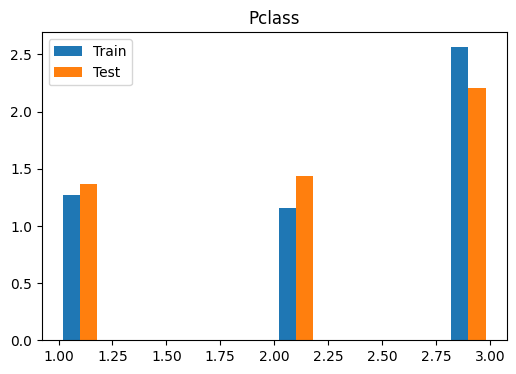

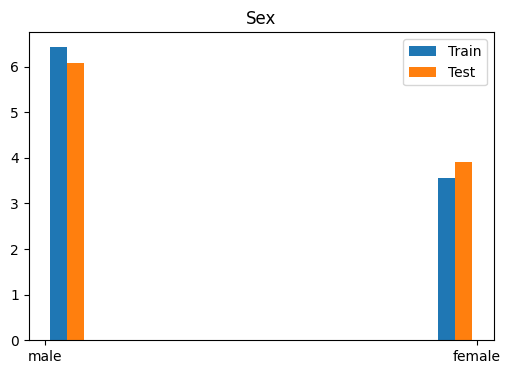

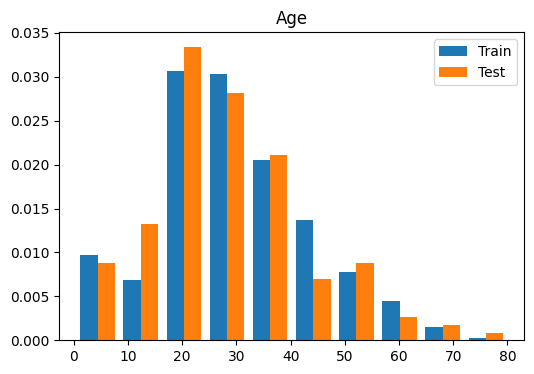

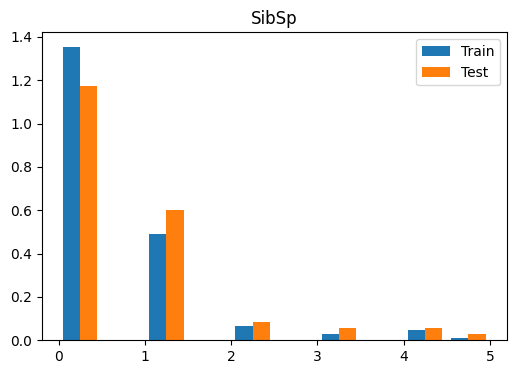

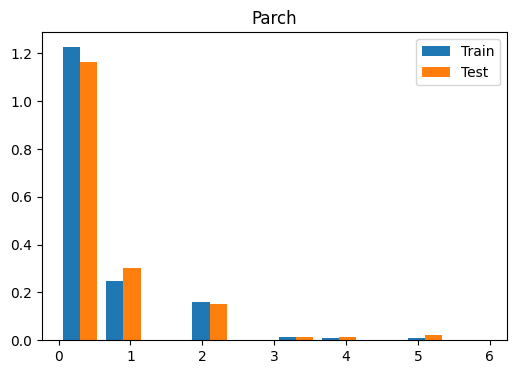

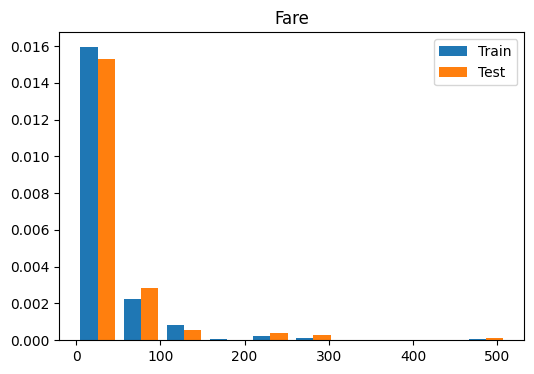

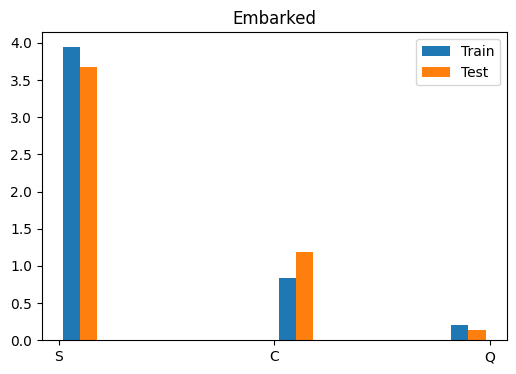

In [1616]:
for col in X_train.columns:
    plt.figure(figsize=(6,4))

    plt.hist([X_train[col].dropna(), X_test[col].dropna()], label = ['Train', 'Test'], density=True, bins=10)
    plt.title(col)
    plt.legend()
    plt.show()

As you can see, some values in specific variables have low sample size. That can be a problem in our models.

In [1617]:
X2 = X.copy()
cols_to_label = [col for col in X2.columns if X2[col].dtype == 'str']

for col in cols_to_label:
    X2[col+'_label'] = le.fit_transform(X2[col])
    X2 = X2.drop(col, axis=1)
    X2 = X2.rename(columns={col+'_label': col})

X_train2, X_test2, Y_train, Y_test = train_test_split(X2,Y,test_size=0.2, random_state=8)


In [1618]:
X_all = pd.concat([Y_train, X_train2], axis=1)

In [1619]:
corr=X_all.corr(method='spearman')

styled = corr.style.format('{:.0%}').map(
    lambda x: 'color: grey' if abs(x)==1 else
    'color: red' if abs(x) >0.8 else
    'color: orange' if abs(x)>0.3 else
    'color: green' if abs(x) < 0.05 else
    'color: white')
display(styled)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
Survived,100%,-37%,-5%,6%,18%,35%,-54%,-15%
Pclass,-37%,100%,-37%,-6%,-3%,-72%,15%,17%
Age,-5%,-37%,100%,-19%,-27%,14%,10%,-2%
SibSp,6%,-6%,-19%,100%,44%,44%,-15%,-3%
Parch,18%,-3%,-27%,44%,100%,42%,-27%,-1%
Fare,35%,-72%,14%,44%,42%,100%,-25%,-17%
Sex,-54%,15%,10%,-15%,-27%,-25%,100%,9%
Embarked,-15%,17%,-2%,-3%,-1%,-17%,9%,100%


If we look at the correlation matrix, we can see that Sex, Fare and Pclass will be the strongest variables in the models. On the other hand, Pclass and Fare are highly corelated. But we will just try to build a model just as it is and see the GINI metric on a train set and test set.

In [1620]:
model = xgb.XGBClassifier(random_state=42)

model.fit(X_train2, Y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [1621]:
predicted_scores = model.predict_proba(X_train2)[:,1]

def gini(y_true, y_pred):
    return 2*roc_auc_score(y_true,y_pred)-1

def model_summary(model,model_name, X_train, Y_train, X_test, Y_test):
    y_pred_train = model.predict_proba(X_train)[:,1]
    y_pred_test = model.predict_proba(X_test)[:,1]

    gini_test = gini(Y_test, y_pred_test)
    gini_train = gini(Y_train, y_pred_train)

    df = pd.DataFrame({
        'model name': [model_name],
        'number of predictors': [model.n_features_in_],
        'GINI train': [round(100*gini_train,3)],
        'GINI test': [round(100*gini_test,3)]
    })
    return df

df = model_summary(model,'Basic model',X_train2, Y_train, X_test2, Y_test )
df


,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574


There is a huge problem with overfitting. The model has learnt the patterns by heart. That is not a good model but let's move and try to build another model. Now we will try to transform the dataset and use dummy variables in the second model.

In [1622]:
X_dummy = X.copy()
X_dummy = pd.get_dummies(X_dummy, columns=['Pclass', 'Sex',  'Embarked',   'SibSp', 'Parch'],drop_first=True)

X_train_dummy, X_test_dummy, Y_train, Y_test = train_test_split(X_dummy,Y,test_size=0.2, random_state=8)
X_all = pd.concat([Y_train,X_train_dummy], axis=1)

X_test_dummy = X_test_dummy.reindex(columns = X_train_dummy.columns, fill_value = 0)
X_all_dummy = pd.concat([Y_train, X_train_dummy], axis=1)

In [1623]:
X_train_dummy.head()

,Age,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6
0,22.00,7.250,False,True,True,False,True,True,False,False,False,False,False,False,False,False,False,False
655,24.00,73.500,True,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False
228,18.00,13.000,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False
78,0.83,29.000,True,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False
729,25.00,7.925,False,True,False,False,True,True,False,False,False,False,False,False,False,False,False,False


That is our dataset now after that transformation.

In [1624]:
model2 = XGBClassifier()

In [1625]:
model2.fit(X_train_dummy, Y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [1626]:
df = pd.concat([df, model_summary(model2, 'Model dummy',X_train_dummy, Y_train, X_test_dummy, Y_test)], axis=0)
df

,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685


Still we have a problem with overfitting but the GINI value on a test set is higher. Maybe we can try to optimize hyperparameters just to reduce overfitting.

In [1627]:
model3 = xgb.XGBClassifier(random_state=42)

param_space={
    'n_estimators': Integer(50,750),
    'max_depth':Integer(3,10),
    'min_child_weight': Integer(3,20),
    'learning_rate': Real(0.05, 0.2, prior = 'log-uniform'),
    'subsample': Real(0.6, 0.9),
    'colsample_bytree': Real(0.6, 0.9),
    'gamma': Real(0.1, 5, prior='log-uniform'),
    'reg_lambda':Real(1,10, prior='log-uniform'),
    'reg_alpha':Real(1,5, prior='log-uniform')
}


grid_search1 = BayesSearchCV(
    estimator=model3,
    search_spaces=param_space,
    scoring='neg_mean_squared_error',
    n_iter=50,
    cv=3,
    verbose=0,
    random_state=42
)

In [1628]:
grid_search1.fit(X_train_dummy, Y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,search_spaces,"{'colsample_bytree': Real(low=0.6,...m='normalize'), 'gamma': Real(low=0.1,...m='normalize'), 'learning_rate': Real(low=0.05...m='normalize'), 'max_depth': Integer(low=3...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'neg_mean_squared_error'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


In [1629]:
model_best = grid_search1.best_estimator_

df = pd.concat([df, model_summary(model_best, 'Model dummy - hyperparameters optimization',X_train_dummy, Y_train, X_test_dummy, Y_test)], axis=0)
df

,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685
0,Model dummy - hyperparameters optimization,18,90.263,74.592


It looks way better but still we have problem with overfitting. Probably we could reduce it if we remove some variables from the model but we would not do it. We will try to group our explanatory variables, I mean the values, to categories basing on decision tree

<Figure size 2500x1200 with 0 Axes>

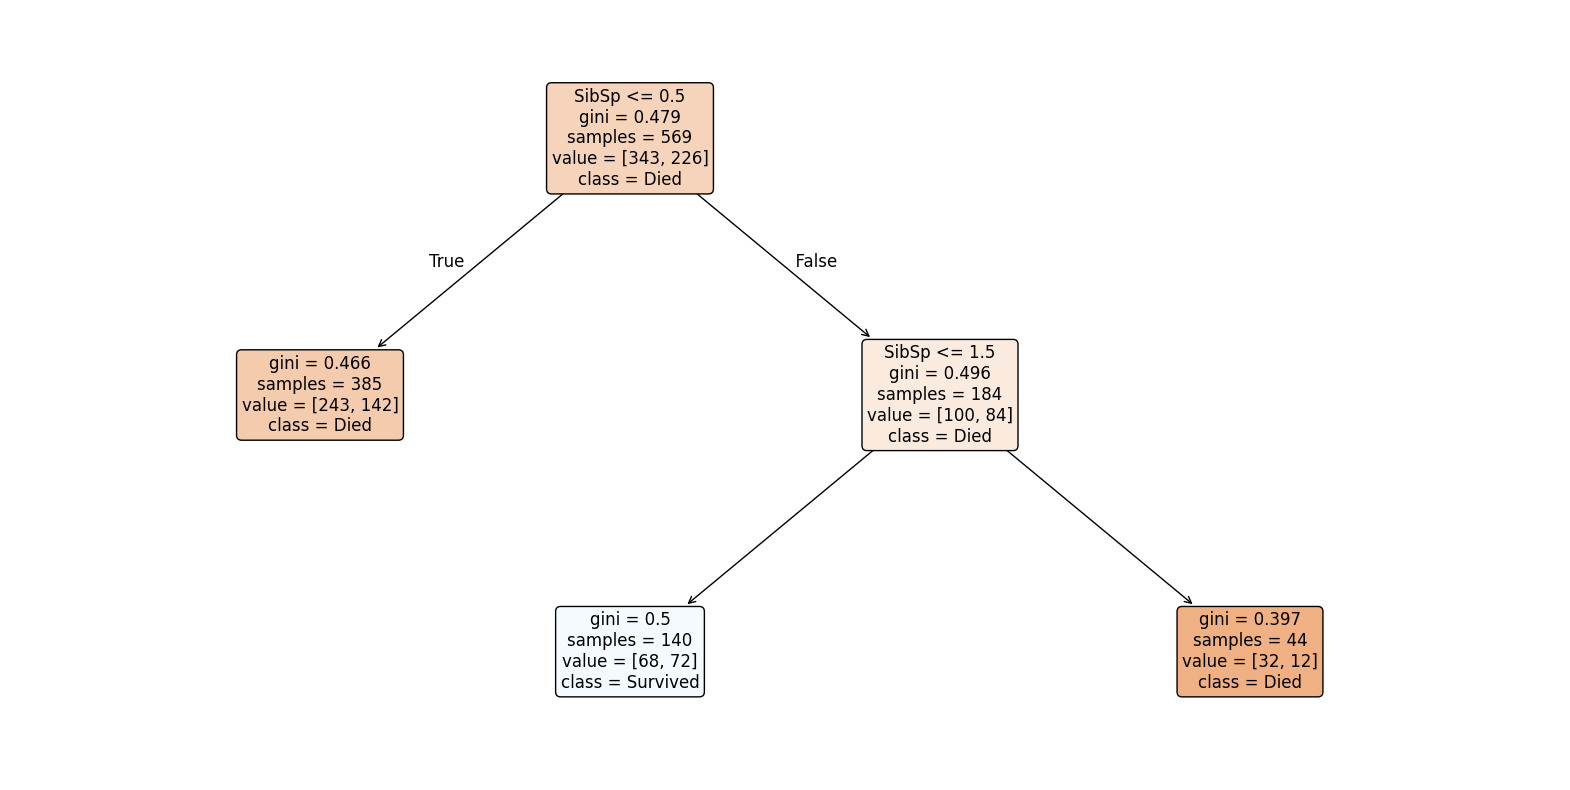

In [1630]:
tree_binning = DecisionTreeClassifier(max_depth=3,min_samples_leaf=30)
tree_binning.fit(X_train[['SibSp']], Y_train)
plt.figure(figsize=(25, 12))

plt.style.use('default')

# 2. STWÓRZ KANWĘ (Z białym tłem dla pewności)
fig, ax = plt.subplots(figsize=(20, 10), facecolor='white')
# 2. Rysujemy drzewo
plot_tree(tree_binning,
          feature_names=['SibSp'],   # Nazwa cechy wejściowej
          class_names=['Died', 'Survived'], # Nazwy klas wyjściowych
          filled=True,           # Wypełnia węzły kolorami (np. niebieski=przeżył)
          rounded=True,          # Zaokrąglone brzegi
          fontsize=12)           # Rozmiar czcionki


plt.show()
#0, 1-2, 3+

<Figure size 2500x1200 with 0 Axes>

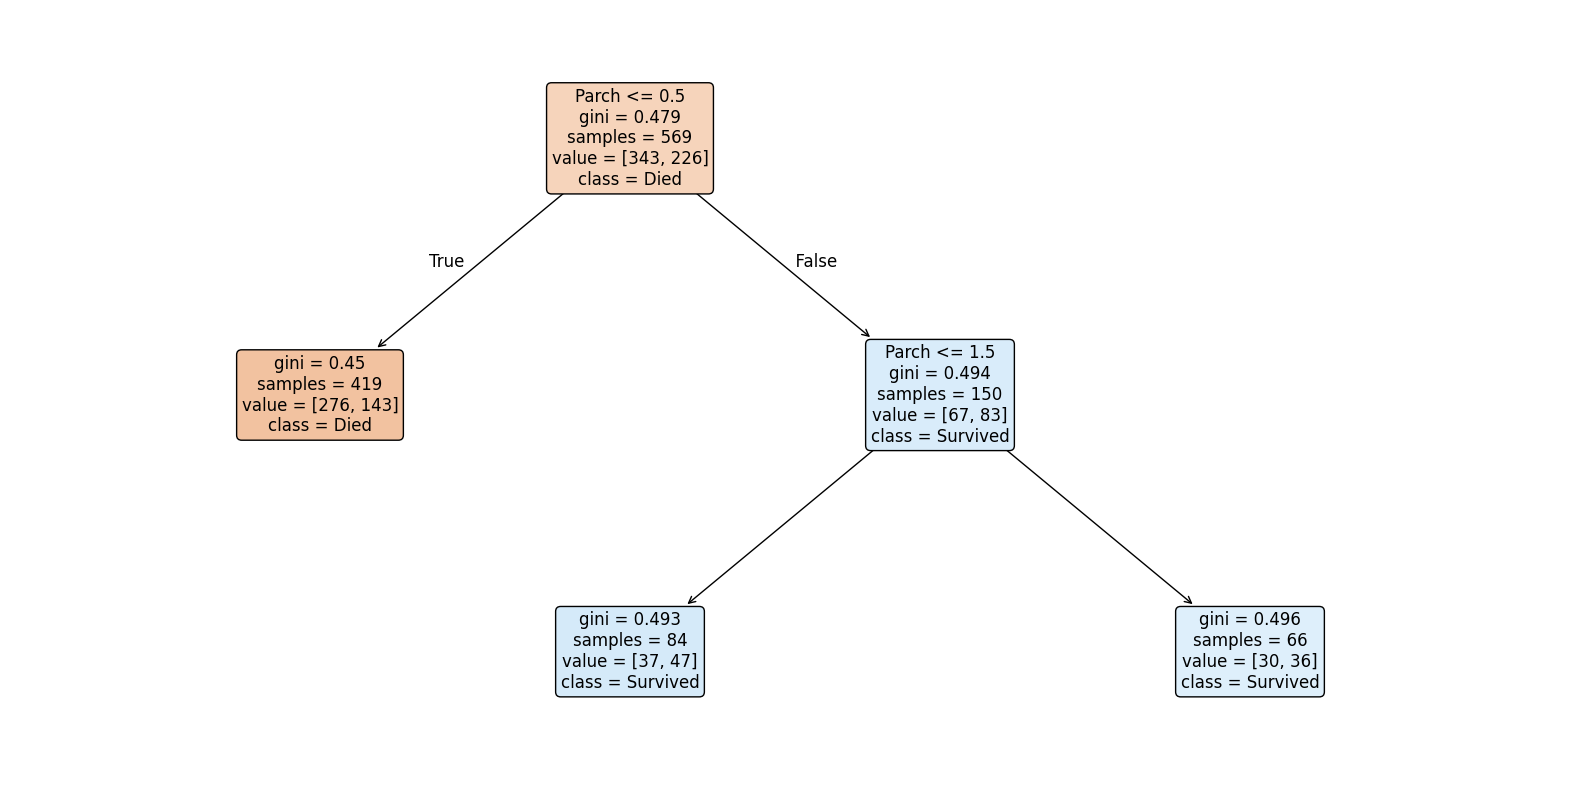

In [1631]:
tree_binning = DecisionTreeClassifier(max_depth=2 ,min_samples_leaf=30)
tree_binning.fit(X_train[['Parch']], Y_train)
plt.figure(figsize=(25, 12))

plt.style.use('default')

# 2. STWÓRZ KANWĘ (Z białym tłem dla pewności)
fig, ax = plt.subplots(figsize=(20, 10), facecolor='white')
# 2. Rysujemy drzewo
plot_tree(tree_binning,
          feature_names=['Parch'],   # Nazwa cechy wejściowej
          class_names=['Died', 'Survived'], # Nazwy klas wyjściowych
          filled=True,           # Wypełnia węzły kolorami (np. niebieski=przeżył)
          rounded=True,          # Zaokrąglone brzegi
          fontsize=12)           # Rozmiar czcionki


plt.show()
#0, 1+

<Figure size 2500x1200 with 0 Axes>

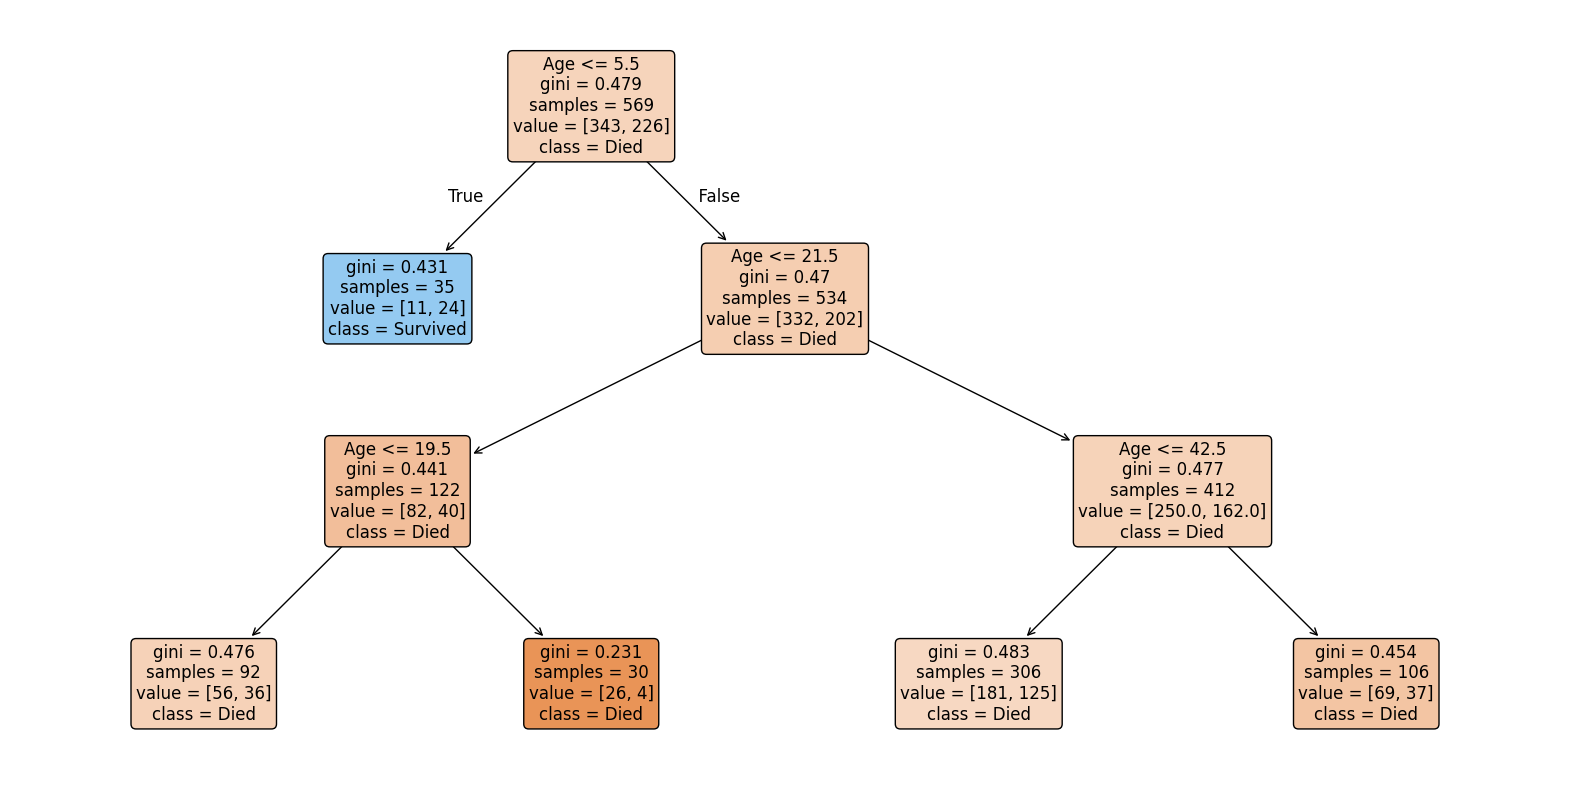

In [1632]:
tree_binning = DecisionTreeClassifier(max_depth=3,min_samples_leaf=30)
tree_binning.fit(X_train[['Age']], Y_train)
plt.figure(figsize=(25, 12))

plt.style.use('default')

# 2. STWÓRZ KANWĘ (Z białym tłem dla pewności)
fig, ax = plt.subplots(figsize=(20, 10), facecolor='white')
# 2. Rysujemy drzewo
plot_tree(tree_binning,
          feature_names=['Age'],   # Nazwa cechy wejściowej
          class_names=['Died', 'Survived'], # Nazwy klas wyjściowych
          filled=True,           # Wypełnia węzły kolorami (np. niebieski=przeżył)
          rounded=True,          # Zaokrąglone brzegi
          fontsize=12)           # Rozmiar czcionki


plt.show()

<Figure size 2500x1200 with 0 Axes>

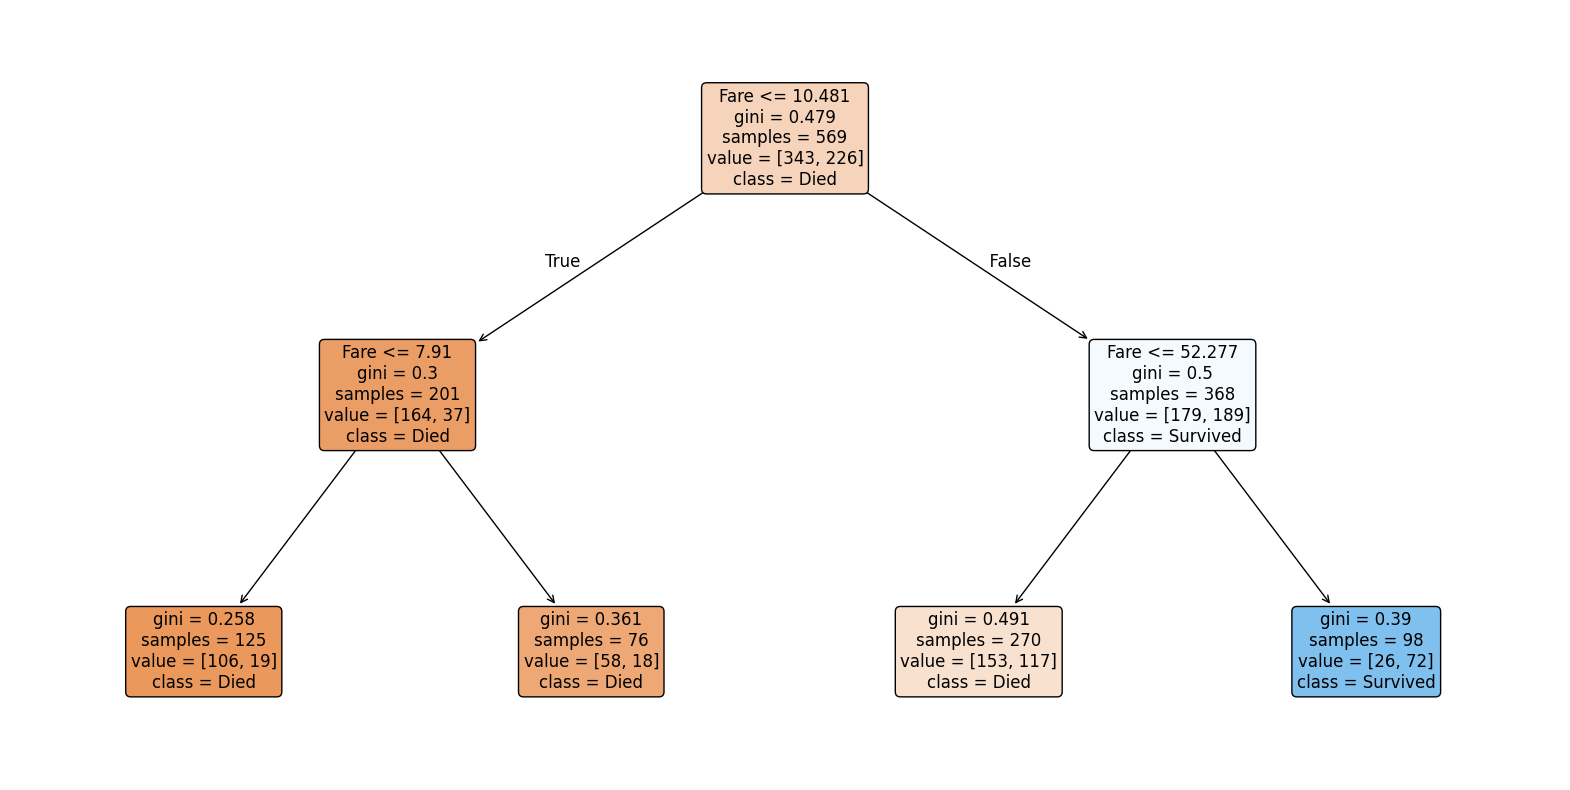

In [1633]:
tree_binning = DecisionTreeClassifier(max_depth=2,min_samples_leaf=30)
tree_binning.fit(X_train[['Fare']], Y_train)
plt.figure(figsize=(25, 12))

plt.style.use('default')

# 2. STWÓRZ KANWĘ (Z białym tłem dla pewności)
fig, ax = plt.subplots(figsize=(20, 10), facecolor='white')
# 2. Rysujemy drzewo
plot_tree(tree_binning,
          feature_names=['Fare'],   # Nazwa cechy wejściowej
          class_names=['Died', 'Survived'], # Nazwy klas wyjściowych
          filled=True,           # Wypełnia węzły kolorami (np. niebieski=przeżył)
          rounded=True,          # Zaokrąglone brzegi
          fontsize=12)           # Rozmiar czcionki


plt.show()

In [1634]:
X_category = X.copy()

def category_sibsp(x):
    if x ==0:
        return 'Alone'
    elif x<=1 :
        return 'Small_family'
    else:
        return 'Big_family'

def category_parch(x):
    if x ==0:
        return 'Alone'
    elif x>=1:
        return 'NotAlone'




def category_age(x):
    if x <= 5 :
        return 'Baby'
    elif x <=21:
        return 'Teenager'

    elif x<=42:
        return 'Adult'
    else:
        return 'Senior'

def category_fare(x):
    if x <= 10.481 :
        return 'Low'
    elif x <=52.277:
        return 'Mid'

    else:
        return 'High'

X_category['SibSp'] = X_category['SibSp'].apply(category_sibsp)

X_category['Parch'] = X_category['Parch'].apply(category_parch)



X_category['Age'] = X_category['Age'].apply(category_age)

X_category['Fare'] = X_category['Fare'].apply(category_fare)

Trees were created and we split four variables to dummy variables and we groupped some values into categories. For instance for age the first category is "Baby" if a passenger is under 5 years old. Teenager - under 22, Adult - under 43, Senior - more or equal 43. For Parch if the passenger did not have a parent or child on board we have a category Alone, in other case NotAlone. For SibSp, if someone did not have any sibling on board nor spouse then they belong to category Alone. If they have on spouse or one sibling then Small_family. In other case we created a category Big_family. For Fare variable there are categories Low, Mid and High and they depend on the prices for the ticket.

In [1635]:
X_category.head(n=10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,Adult,Small_family,Alone,Low,S
1,1,female,Adult,Small_family,Alone,High,C
2,3,female,Adult,Alone,Alone,Low,S
3,1,female,Adult,Small_family,Alone,High,S
4,3,male,Adult,Alone,Alone,Low,S
6,1,male,Senior,Alone,Alone,Mid,S
7,3,male,Baby,Big_family,NotAlone,Mid,S
8,3,female,Adult,Alone,NotAlone,Mid,S
9,2,female,Teenager,Small_family,Alone,Mid,C
10,3,female,Baby,Small_family,NotAlone,Mid,S


In [1636]:
X_category = pd.get_dummies(X_category, columns=['Sex','SibSp','Parch',  'Embarked', 'Pclass','Age' ,'Fare' ], drop_first=True)


In [1637]:
X_train_category, X_test_category, Y_train, Y_test = train_test_split(X_category,Y,test_size=0.2, random_state=8)

X_train_category, X_val_category, Y_train, Y_val = train_test_split(X_train_category,Y_train,test_size=0.25, random_state=8)

Let's build a model then. For now without optimizing hyperparameters.

In [1638]:
model_category = XGBClassifier()

model_category.fit(X_train_category, Y_train)

df = pd.concat([df, model_summary(model_category, 'Model dummy - categories',X_train_category, Y_train, X_test_category, Y_test)], axis=0)
df

,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685
0,Model dummy - hyperparameters optimization,18,90.263,74.592
0,Model dummy - categories,13,89.099,63.082


It did not help at all. Maybe if we optimize hyperparameters it will help somehow.

In [1639]:
model_category_grid = xgb.XGBClassifier(
    random_state=42,
)
param_space={
    'n_estimators': Integer(50,750),
    'max_depth':Integer(3,10),
    'min_child_weight': Integer(3,20),
    'learning_rate': Real(0.05, 0.2, prior = 'log-uniform'),
    'subsample': Real(0.6, 0.9),
    'colsample_bytree': Real(0.6, 0.9),
    'gamma': Real(0.1, 5, prior='log-uniform'),
    'reg_lambda':Real(1,10, prior='log-uniform'),
    'reg_alpha':Real(1,5, prior='log-uniform')
}

grid_search1 = BayesSearchCV(
    estimator=model_category_grid,
    search_spaces=param_space,
    scoring='roc_auc',
    n_iter=50,
    cv=3,
    verbose=0,
    random_state=42
)

grid_search1.fit(X_train_category, Y_train)

model_best_category = grid_search1.best_estimator_



In [1640]:
# dopiero teraz early stopping
model_best_category.fit(
    X_train_category, Y_train,
    verbose=False
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.6593598062798292
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

In [1641]:
df = pd.concat([df, model_summary(model_best_category, 'Model dummy - categories - hyperparameters optimization',X_train_category, Y_train, X_val_category, Y_val)], axis=0)
df

#


,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685
0,Model dummy - hyperparameters optimization,18,90.263,74.592
0,Model dummy - categories,13,89.099,63.082
0,Model dummy - categories - hyperparameters opt...,13,80.818,70.437


It helped, we reduced GINI value on a train set. Now we will try to reduce that overfitting. It is not that bad as it was, but probably we have some unnecesary variables in the model. We will base on permutation importance value and standard deviation for permuation importance. Also on feature importance. But the most important chart will be how the GINI value changes if we add aditional variable to the model.

In [1642]:
def get_feats_plots(model,set, df_variables, y, n_repeats=20, random_state=42):
    per_imp = permutation_importance(model, df_variables, y, n_repeats=n_repeats, random_state=random_state,scoring='roc_auc').importances_mean
    per_imp_std = permutation_importance(model, df_variables, y, n_repeats=n_repeats, random_state=random_state,scoring='roc_auc').importances_std
    feat_importance = model.feature_importances_

    sort_idx_pi = np.argsort(per_imp)
    sort_idx_fi = np.argsort(feat_importance)

    sort_pi = df_variables.columns[sort_idx_pi]
    sort_fi = df_variables.columns[sort_idx_fi]

    fig, axes = plt.subplots(1, 3, figsize=(18, len(sort_idx_pi) * 0.3 + 2))

    axes[0].barh(sort_fi,feat_importance[sort_idx_fi], color='green')
    axes[0].set_title('Feature Importance ' + set)
    axes[1].barh(sort_pi, per_imp[sort_idx_pi], color = 'red')
    axes[1].set_title('Permutation Importance ' + set)

    axes[2].barh(sort_pi, per_imp_std[sort_idx_pi], color = 'red')
    axes[2].set_title('Permutation Importance - Std ' + set)
    axes[2].set_xlim(0,axes[1].get_xlim()[1])
    plt.tight_layout()
    plt.show()





In [1643]:
def gini_przyrost(model,set,X_train, Y_train, X,Y,X_val, y_val):
    importance1 = pd.Series(permutation_importance(model, X_val, y_val, n_repeats=20, random_state=42,scoring='roc_auc').importances_mean, index = X_val.columns)
    importance1 = importance1.sort_values(ascending=False)

    sorted_features = list(importance1.index)
    gini_scores = []
    feature_labels = []
    for i in range(1, len(sorted_features)+1):
        top_features = sorted_features[:i]
        feature_labels.append(", ".join(top_features))
        model_temp = xgb.XGBClassifier(**grid_search1.best_params_, random_state=42)
        model_temp.fit(X_train[top_features], Y_train)

        probas = model_temp.predict_proba(X[top_features])[:, 1]

        gini_val = gini(Y, probas)

        gini_scores.append(gini_val)

    plt.figure(figsize=(10,6))
    plt.plot(sorted_features, gini_scores, marker='o')
    plt.title("Increase GINI "+set)
    plt.xlabel("Number of variables")
    plt.ylabel("GINI")
    plt.xticks(rotation='vertical')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [1644]:
X_all_category = pd.concat([  Y_train,X_train_category ], axis=1)
X_all_category_val = pd.concat([ Y_val,X_val_category  ], axis=1)
X_all_category_test = pd.concat([ Y_test,X_test_category  ], axis=1)

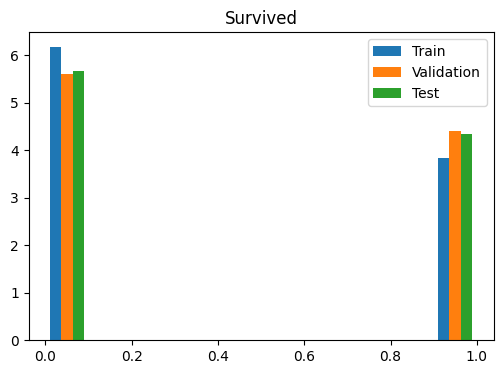

C:\Users\mporc\OneDrive\Dokumenty\Premierleague_2526_database\venv\Lib\site-packages\matplotlib\axes\_axes.py:7117: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bins = np.histogram_bin_edges(
C:\Users\mporc\OneDrive\Dokumenty\Premierleague_2526_database\venv\Lib\site-packages\matplotlib\axes\_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


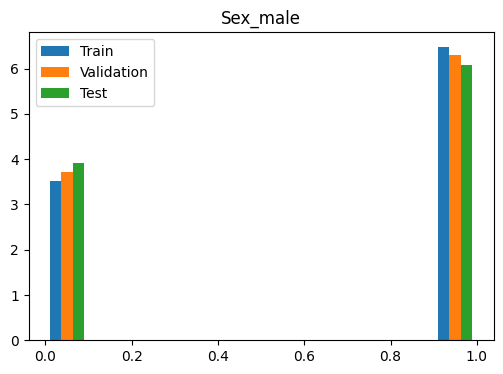

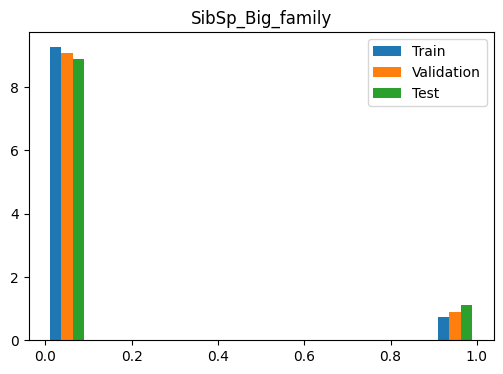

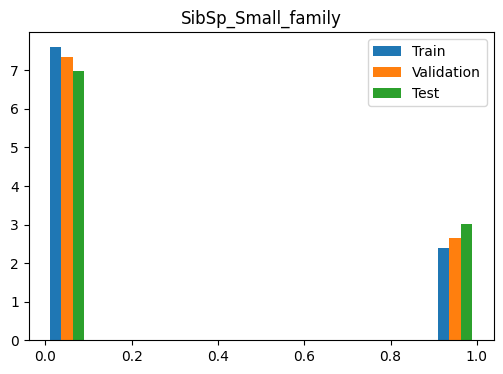

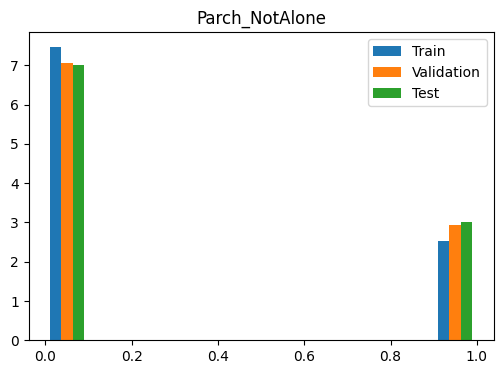

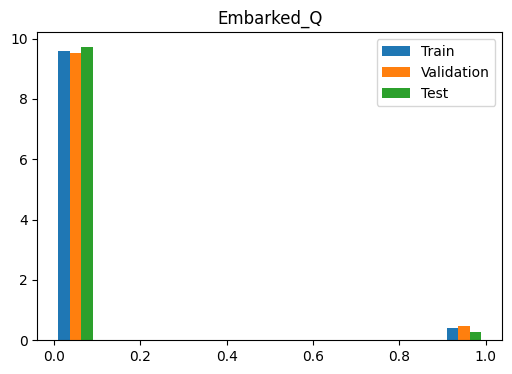

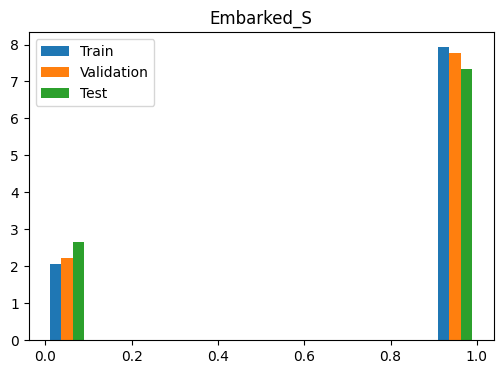

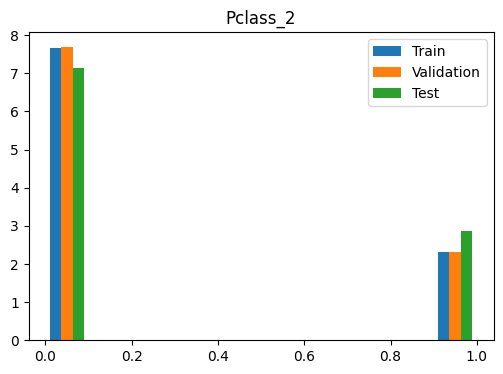

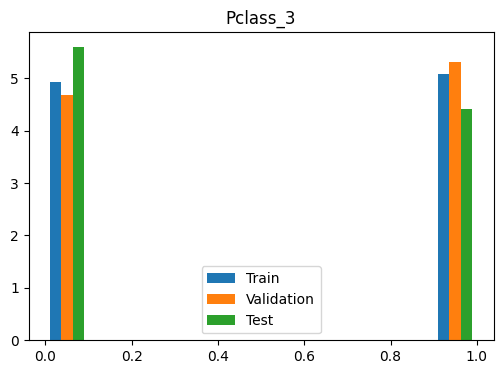

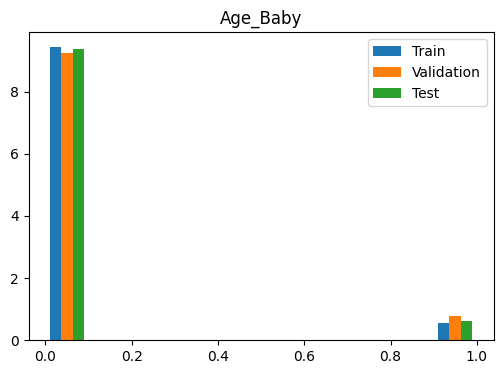

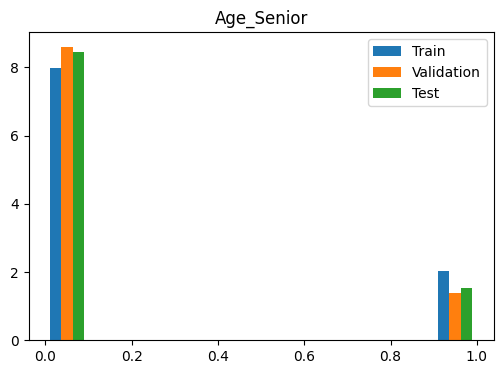

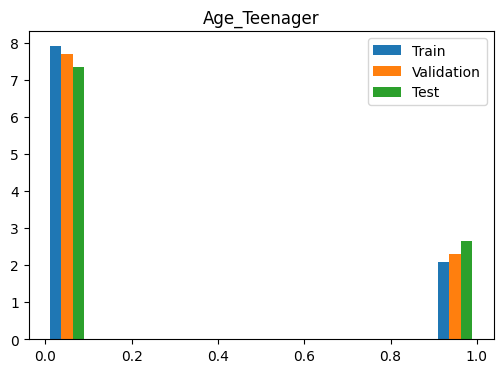

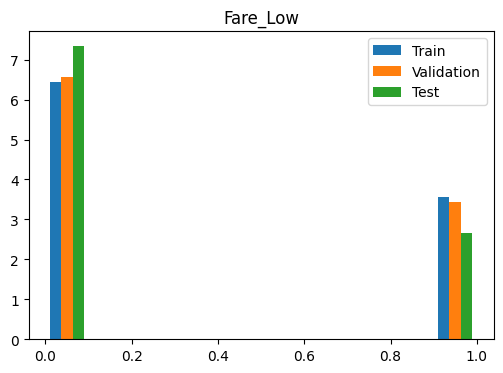

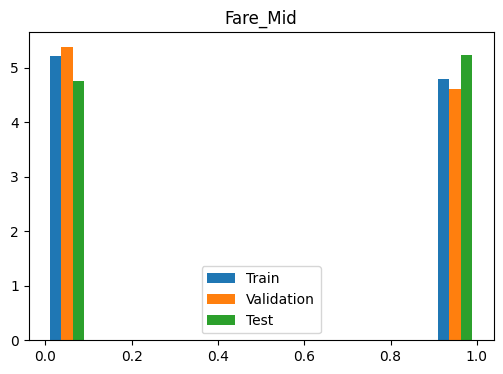

In [1645]:
for col in X_all_category:
    plt.figure(figsize=(6,4))

    plt.hist([X_all_category[col].dropna(), X_all_category_val[col].dropna(),X_all_category_test[col].dropna()], label = ['Train','Validation', 'Test'], density=True, bins=10)
    plt.title(col)
    plt.legend()
    plt.show()

We can also use correlation matrix for that purpose. Variable that is highly corelated with explanatory variable probable brings some information to the model. The most significant is for sure whether a passenger was a male or female. Then also if he had a room in third class or not.

We should also mention that we created validation set to choose the best variables for the model. If we did it on test set, we would suffer from data leakage. We do not want that.

In [1646]:
corr=X_all_category.corr(method='spearman')

styled = corr.style.format('{:.0%}').map(
    lambda x: 'color: black' if abs(x)==1 else
    'color: red' if abs(x) >0.8 else
    'color: orange' if abs(x)>0.3 else
    'color: green' if abs(x) < 0.1 else
    'color: grey')
display(styled)

,Survived,Sex_male,SibSp_Big_family,SibSp_Small_family,Parch_NotAlone,Embarked_Q,Embarked_S,Pclass_2,Pclass_3,Age_Baby,Age_Senior,Age_Teenager,Fare_Low,Fare_Mid
Survived,100%,-55%,-11%,16%,16%,-4%,-14%,9%,-33%,12%,-5%,-6%,-29%,8%
Sex_male,-55%,100%,-2%,-16%,-28%,-0%,7%,-11%,17%,-10%,5%,-4%,27%,-13%
SibSp_Big_family,-11%,-2%,100%,-16%,29%,13%,3%,-3%,8%,25%,-7%,17%,-21%,18%
SibSp_Small_family,16%,-16%,-16%,100%,22%,-11%,-4%,7%,-15%,5%,-4%,-7%,-29%,9%
Parch_NotAlone,16%,-28%,29%,22%,100%,-4%,-1%,4%,-4%,40%,-8%,5%,-37%,25%
Embarked_Q,-4%,-0%,13%,-11%,-4%,100%,-40%,-8%,15%,5%,-1%,7%,15%,-10%
Embarked_S,-14%,7%,3%,-4%,-1%,-40%,100%,17%,5%,-0%,-3%,2%,5%,14%
Pclass_2,9%,-11%,-3%,7%,4%,-8%,17%,100%,-56%,-1%,-6%,-8%,-41%,53%
Pclass_3,-33%,17%,8%,-15%,-4%,15%,5%,-56%,100%,10%,-24%,22%,70%,-34%
Age_Baby,12%,-10%,25%,5%,40%,5%,-0%,-1%,10%,100%,-12%,-13%,-14%,17%


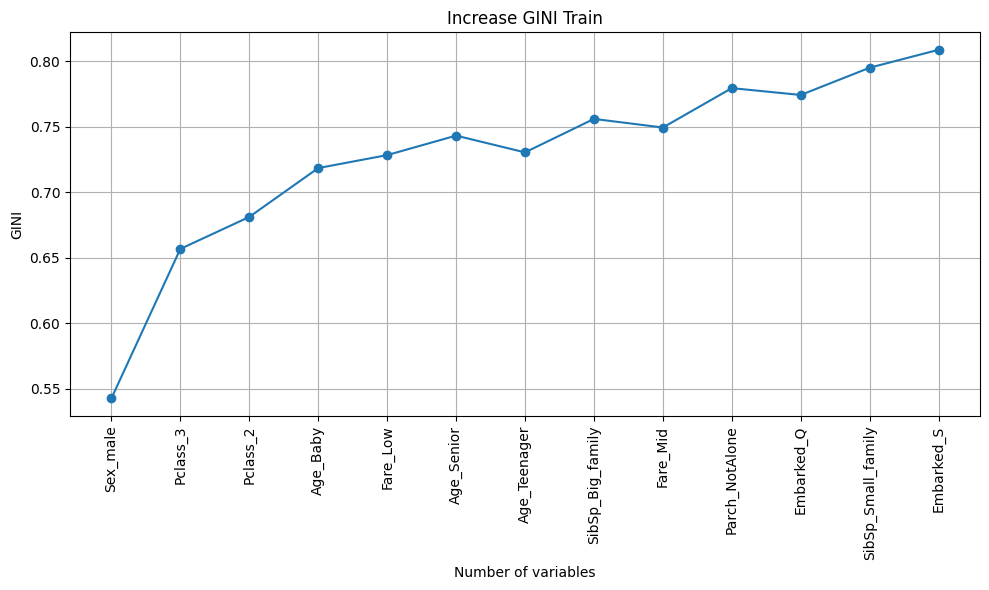

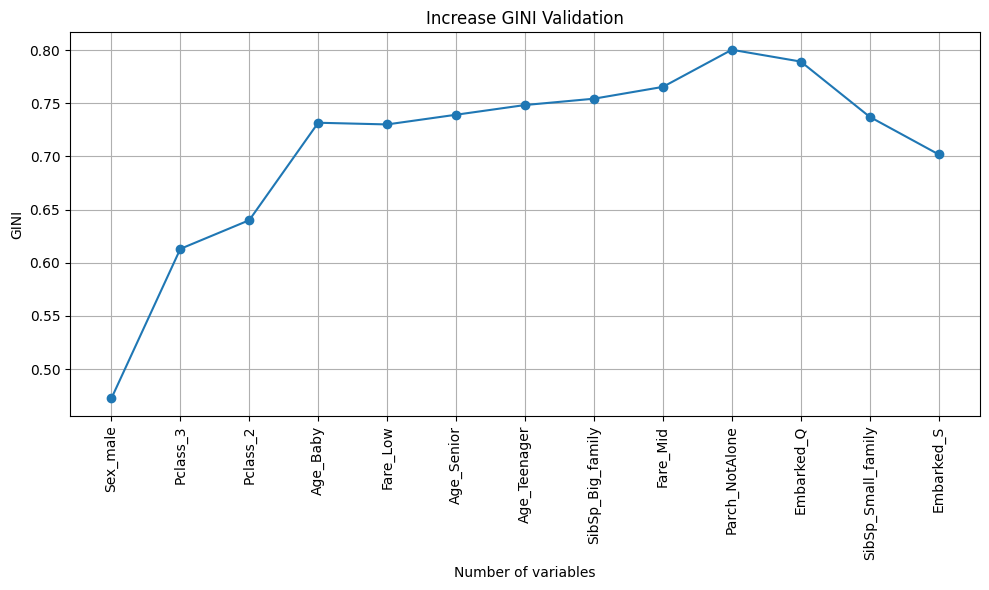

In [1647]:
gini_przyrost(model_best_category,'Train',X_train_category, Y_train, X_train_category, Y_train, X_val_category, Y_val)
gini_przyrost(model_best_category,'Validation',X_train_category, Y_train, X_val_category, Y_val, X_val_category, Y_val)


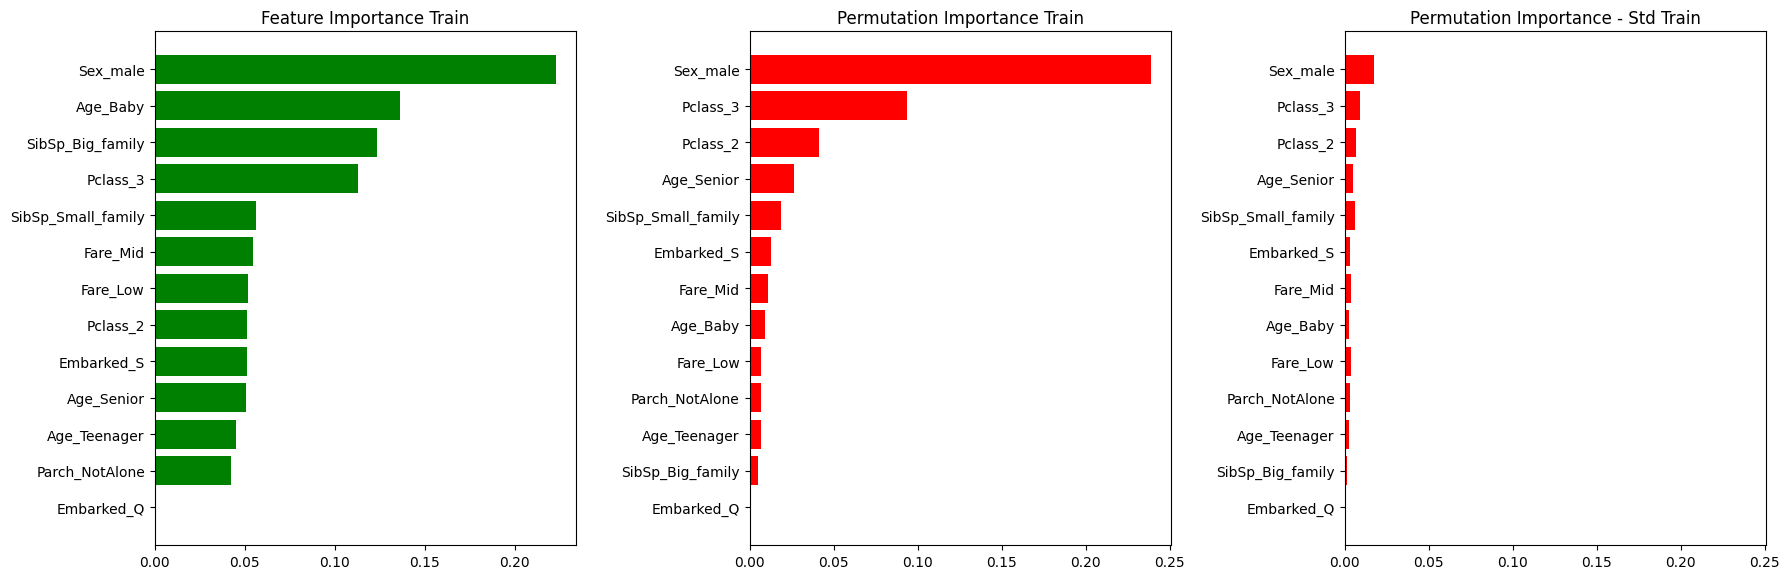

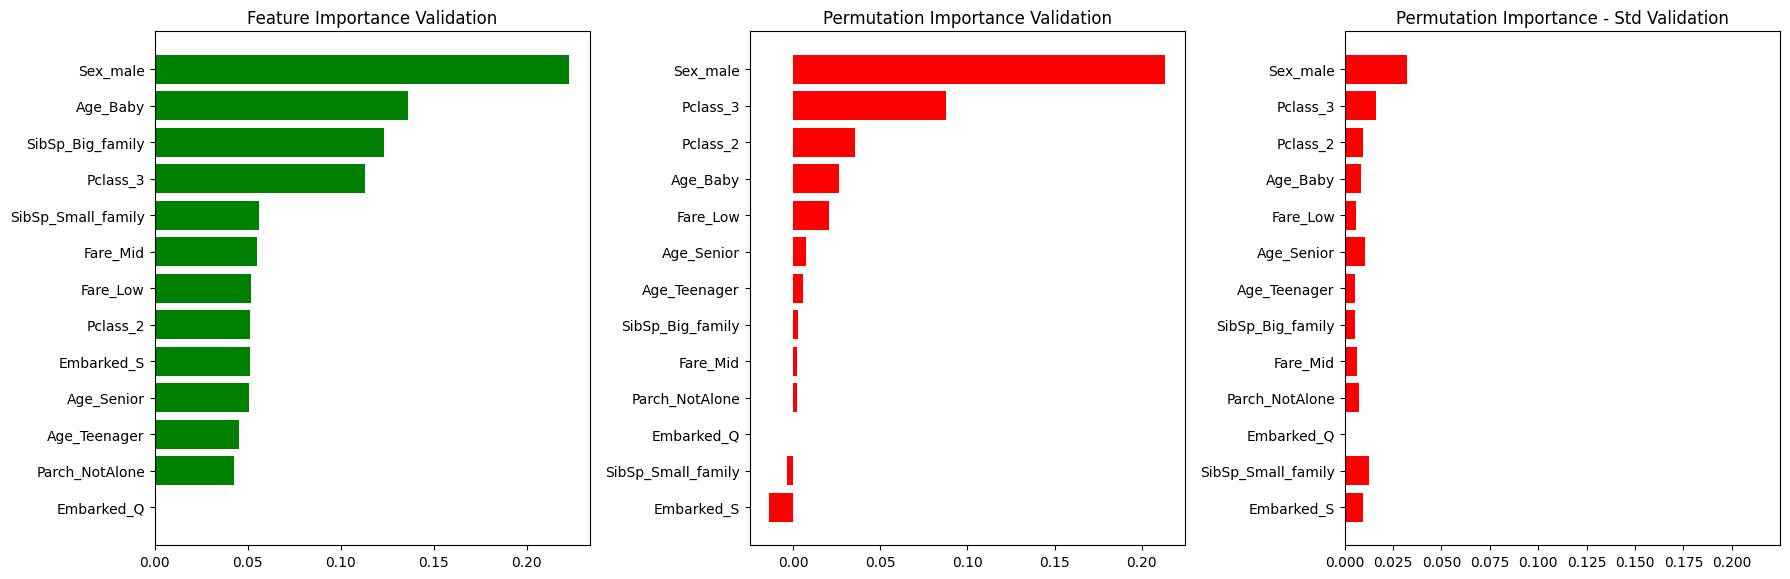

In [1648]:
get_feats_plots(model_best_category,'Train' ,X_train_category, Y_train)
get_feats_plots(model_best_category, 'Validation',X_val_category, Y_val)


The first variable that we will drop is Embarked_S. It is because it lowers the GINI value on a valid set (and makes it higher on train set, that variable can cause overfitting). Also it has a negative Permutation Importance value on a validation set and high standard deviation.

In [1649]:
X_train_category_del1 = X_train_category.drop([ 'Embarked_S'], axis=1)
X_test_category_del1 = X_test_category.drop([ 'Embarked_S'], axis=1)
X_val_category_del1 = X_val_category.drop([ 'Embarked_S'], axis=1)

model_best_category.fit(X_train_category_del1, Y_train)

df = pd.concat([df, model_summary(model_best_category, 'Model dummy - categories -  variable deduction 1',X_train_category_del1, Y_train, X_val_category_del1, Y_val)], axis=0)
df

,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685
0,Model dummy - hyperparameters optimization,18,90.263,74.592
0,Model dummy - categories,13,89.099,63.082
0,Model dummy - categories - hyperparameters opt...,13,80.818,70.437
0,Model dummy - categories - variable deduction 1,12,80.149,73.651


We improved the resuls on a test (in our case validation) set. Now we will try to look for the other variables to remove.

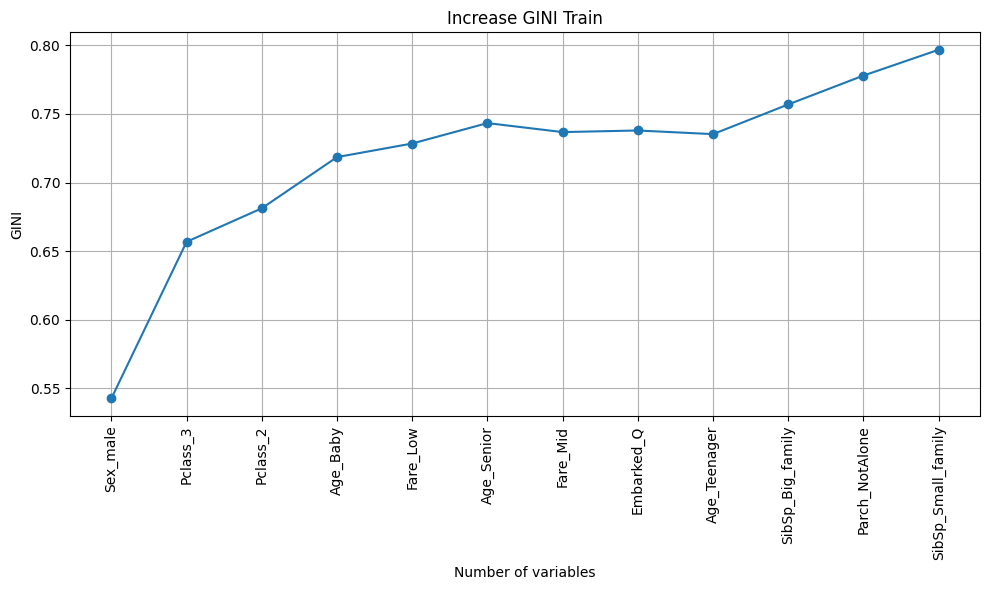

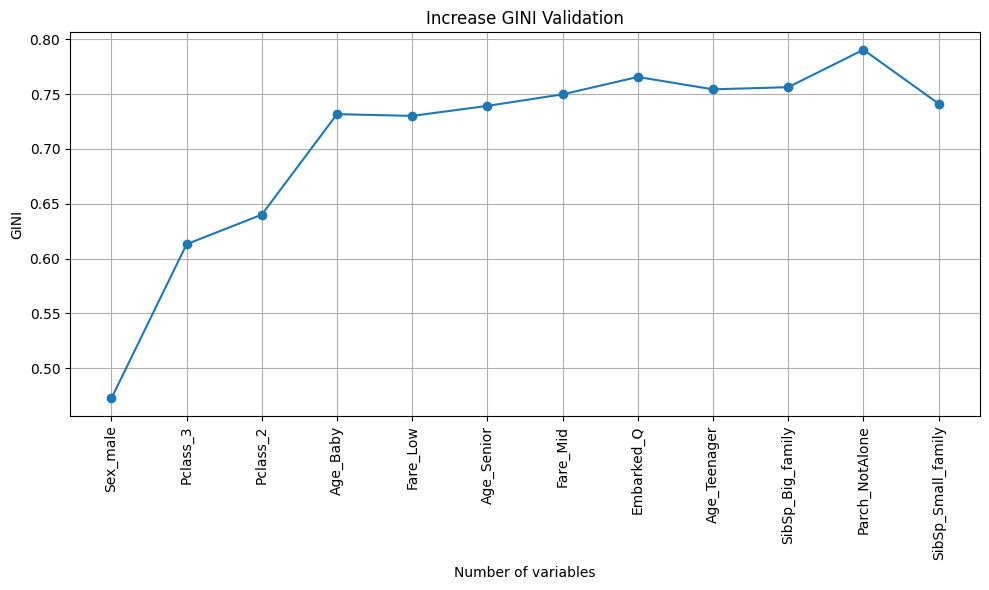

In [1650]:
gini_przyrost(model_best_category,'Train',  X_train_category_del1, Y_train,X_train_category_del1, Y_train, X_val_category_del1, Y_val)
gini_przyrost(model_best_category, 'Validation', X_train_category_del1, Y_train, X_val_category_del1, Y_val, X_val_category_del1, Y_val)


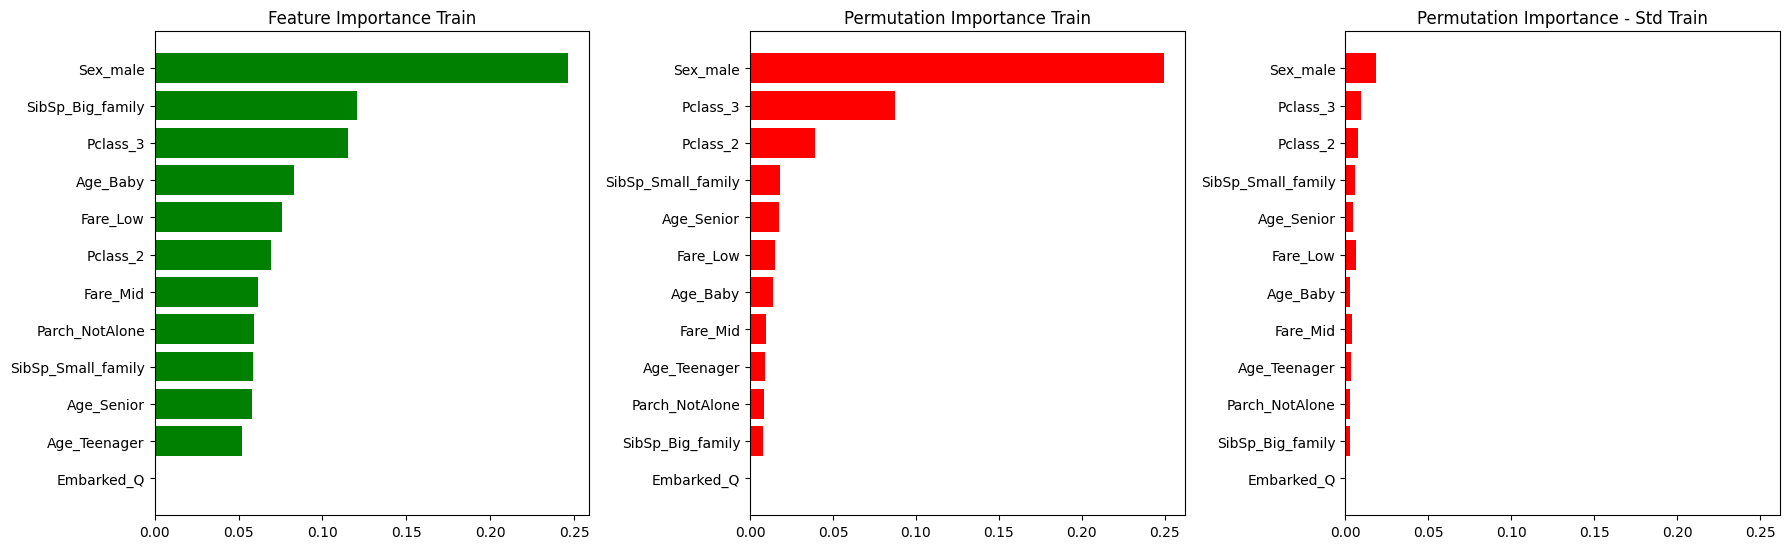

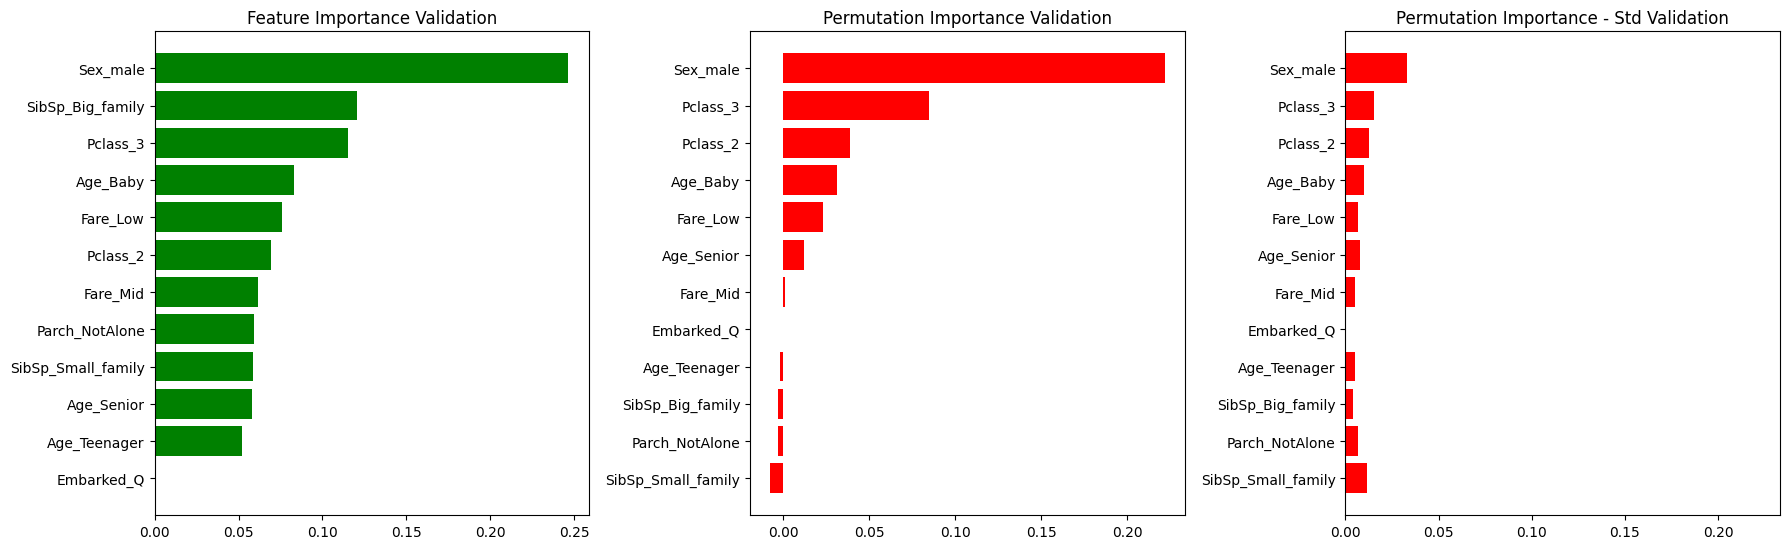

In [1651]:
get_feats_plots(model_best_category,'Train' ,X_train_category_del1, Y_train)
get_feats_plots(model_best_category, 'Validation',X_val_category_del1, Y_val)


Due to the negative permuation importance value on validation set we will remove SibSp_Small_family variable from the model. It also causes overfitting.

In [1652]:
X_train_category_del2 = X_train_category_del1.drop(['SibSp_Small_family'], axis =1)
X_test_category_del2 = X_test_category_del1.drop(['SibSp_Small_family'], axis =1)
X_val_category_del2 = X_val_category_del1.drop(['SibSp_Small_family'], axis =1)

model_best_category.fit(X_train_category_del2, Y_train)

df = pd.concat([df, model_summary(model_best_category, 'Model dummy - categories -  variable deduction 2',X_train_category_del2, Y_train, X_val_category_del2, Y_val)], axis=0)
df



,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685
0,Model dummy - hyperparameters optimization,18,90.263,74.592
0,Model dummy - categories,13,89.099,63.082
0,Model dummy - categories - hyperparameters opt...,13,80.818,70.437
0,Model dummy - categories - variable deduction 1,12,80.149,73.651
0,Model dummy - categories - variable deduction 2,11,77.469,77.341


GINI metric on train set and validation is lower than it was but still we reduced overfitting a little bit.

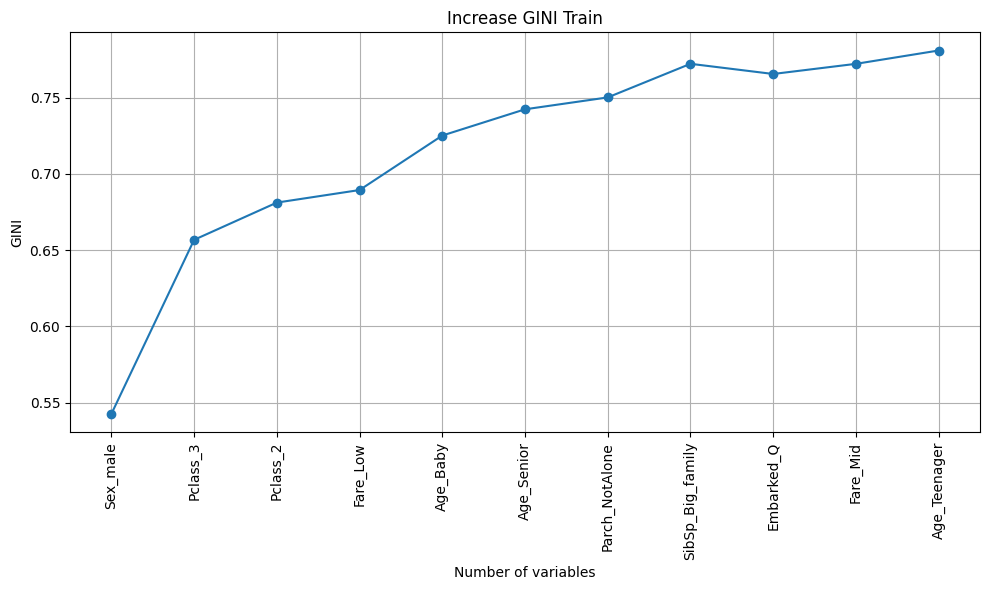

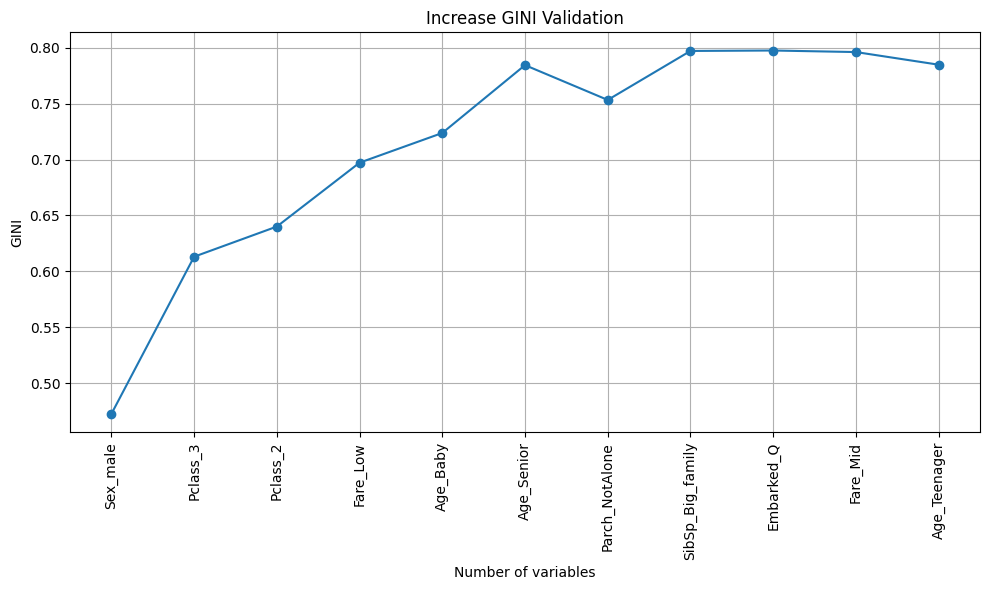

In [1653]:
gini_przyrost(model_best_category, 'Train',X_train_category_del2, Y_train,X_train_category_del2, Y_train, X_val_category_del2, Y_val)
gini_przyrost(model_best_category, 'Validation',X_train_category_del2, Y_train,X_val_category_del2, Y_val, X_val_category_del2, Y_val)


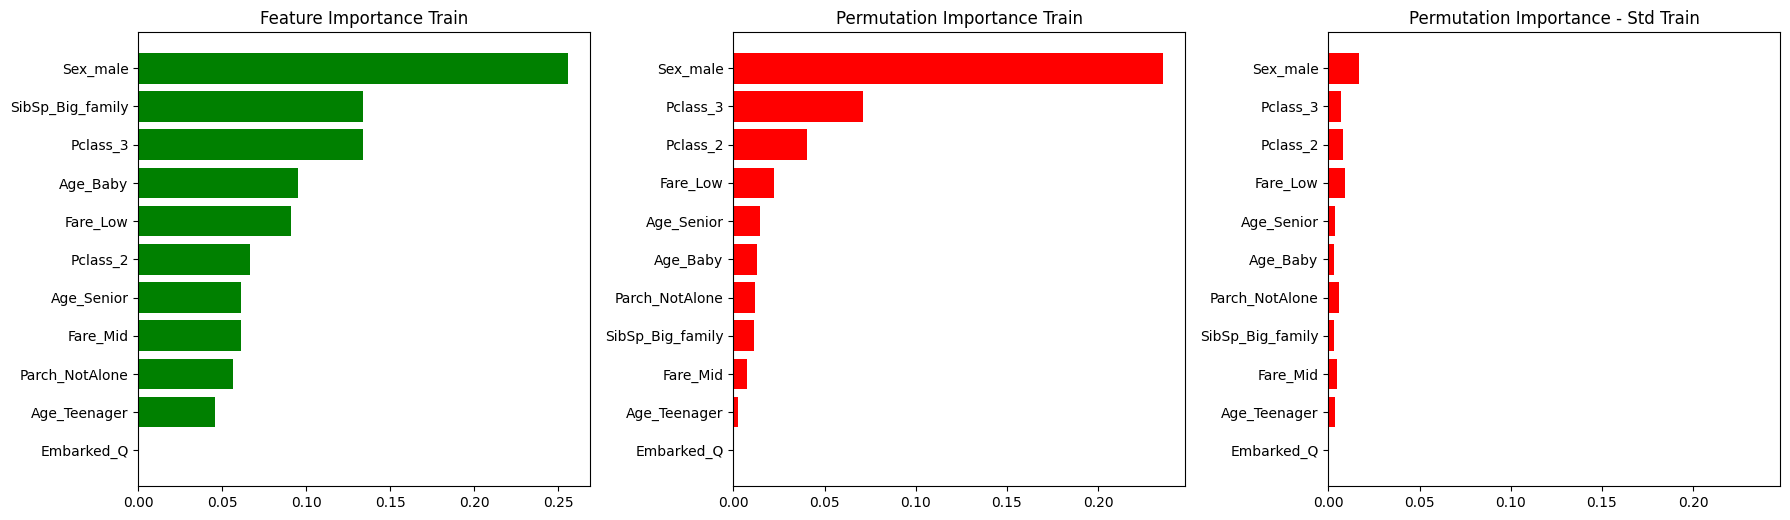

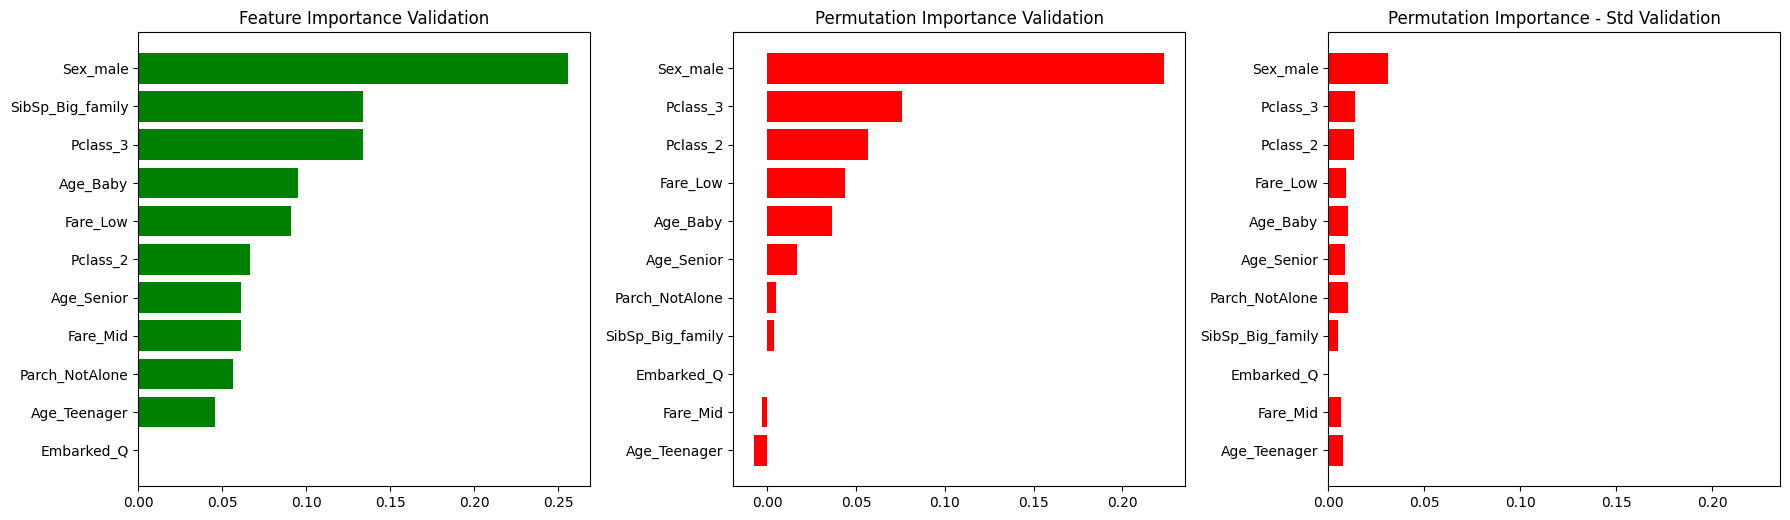

In [1654]:
get_feats_plots(model_best_category, 'Train',X_train_category_del2, Y_train)
get_feats_plots(model_best_category, 'Validation',X_val_category_del2, Y_val)


Embarked_Q seems to be unnecesary for the mode. Low permuation importance and feature importance and also does not improve GINI metric after adding this variable to the model. We want to see how the model reacts without that variable since do not want to remove Age_Teenager of Fare_Mid for now.

In [1655]:
X_train_category_del3 = X_train_category_del2.drop(['Embarked_Q' ], axis =1)
X_test_category_del3 = X_test_category_del2.drop(['Embarked_Q' ], axis =1)
X_val_category_del3 = X_val_category_del2.drop(['Embarked_Q' ], axis =1)

model_best_category.fit(X_train_category_del3, Y_train)

df = pd.concat([df, model_summary(model_best_category, 'Model dummy - categories -  variable deduction 2',X_train_category_del3, Y_train, X_val_category_del3, Y_val)], axis=0)
df

,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685
0,Model dummy - hyperparameters optimization,18,90.263,74.592
0,Model dummy - categories,13,89.099,63.082
0,Model dummy - categories - hyperparameters opt...,13,80.818,70.437
0,Model dummy - categories - variable deduction 1,12,80.149,73.651
0,Model dummy - categories - variable deduction 2,11,77.469,77.341
0,Model dummy - categories - variable deduction 2,10,77.235,79.206


GINI on validation set is higher while on train set remains on the same level.

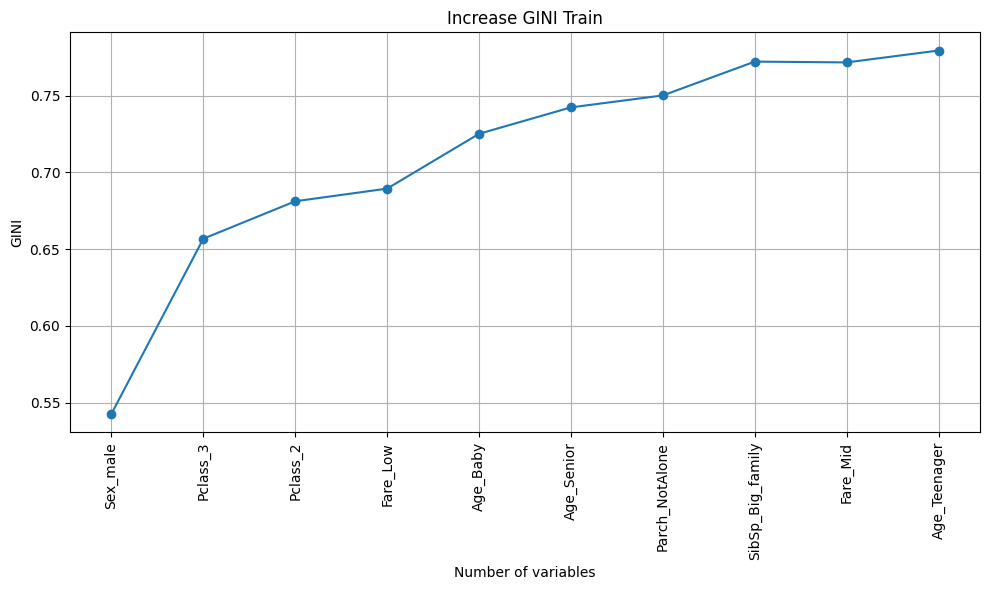

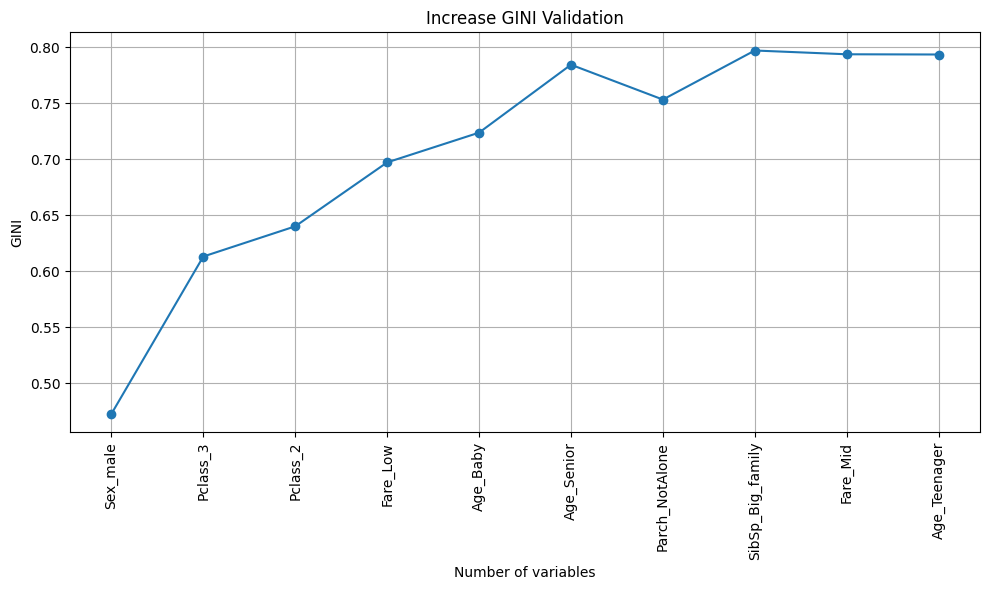

In [1656]:
gini_przyrost(model_best_category, 'Train',X_train_category_del3, Y_train,X_train_category_del3, Y_train, X_val_category_del3, Y_val)
gini_przyrost(model_best_category, 'Validation',X_train_category_del3, Y_train,X_val_category_del3, Y_val, X_val_category_del3, Y_val)


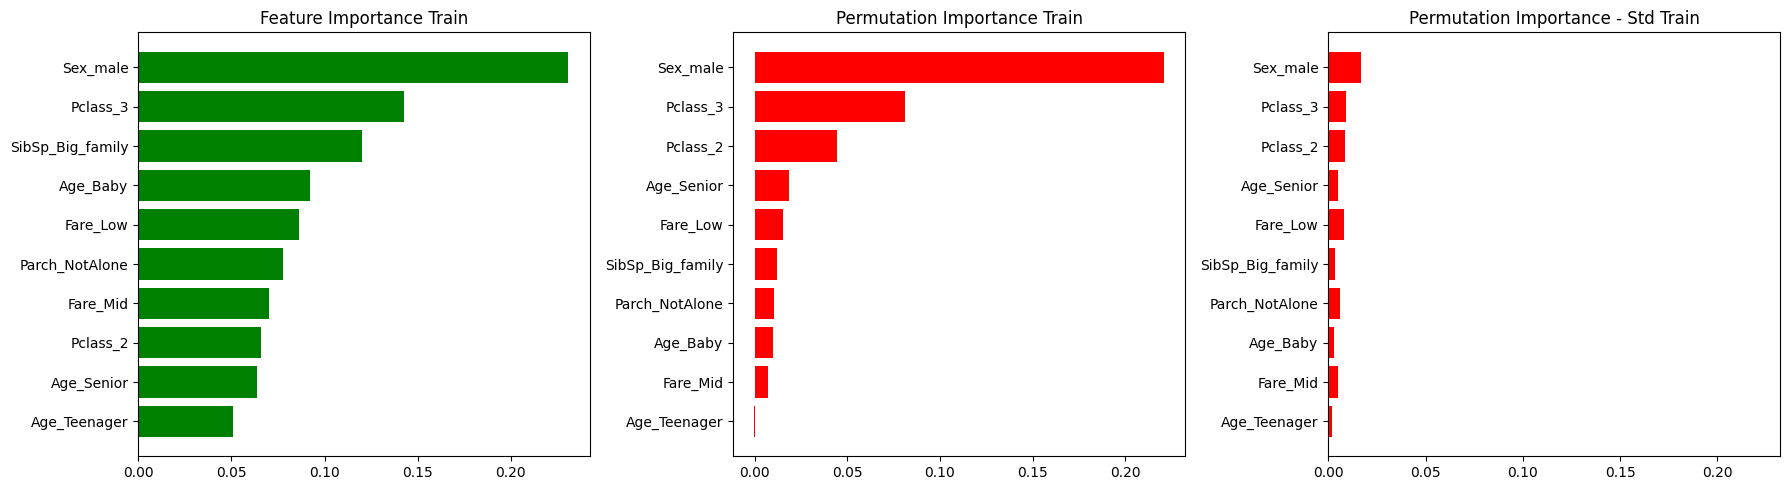

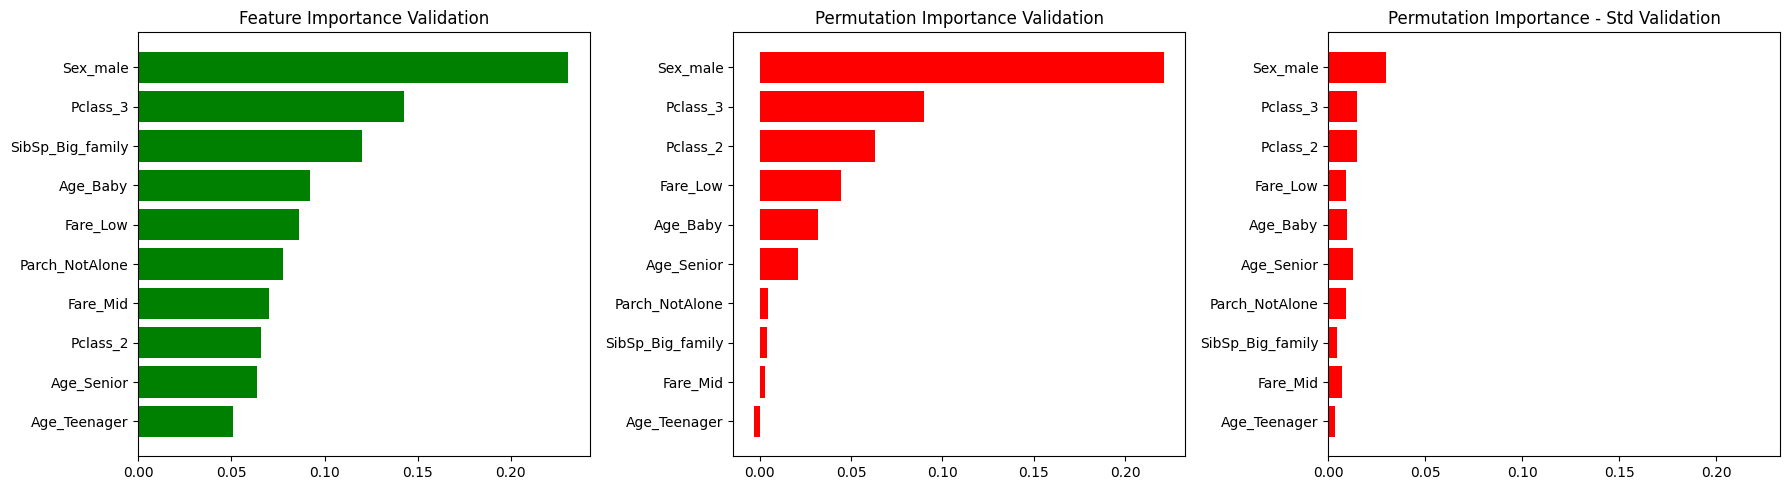

In [1657]:
get_feats_plots(model_best_category,'Train',X_train_category_del3, Y_train)
get_feats_plots(model_best_category,'Validation',X_val_category_del3, Y_val)


Age_Teenager is the only variable with negative permutation importance. Also it does not improve GINI value on validation set at all so we remove it.

In [1658]:
X_train_category_del4 = X_train_category_del3.drop([ 'Age_Teenager'  ], axis =1)
X_test_category_del4 = X_test_category_del3.drop([ 'Age_Teenager'], axis =1)
X_val_category_del4 = X_val_category_del3.drop(['Age_Teenager'], axis =1)

model_best_category.fit(X_train_category_del4, Y_train)

df = pd.concat([df, model_summary(model_best_category, 'Model dummy - categories -  variable deduction 3',X_train_category_del4, Y_train, X_val_category_del4, Y_val)], axis=0)
df

,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685
0,Model dummy - hyperparameters optimization,18,90.263,74.592
0,Model dummy - categories,13,89.099,63.082
0,Model dummy - categories - hyperparameters opt...,13,80.818,70.437
0,Model dummy - categories - variable deduction 1,12,80.149,73.651
0,Model dummy - categories - variable deduction 2,11,77.469,77.341
0,Model dummy - categories - variable deduction 2,10,77.235,79.206
0,Model dummy - categories - variable deduction 3,9,77.163,78.750


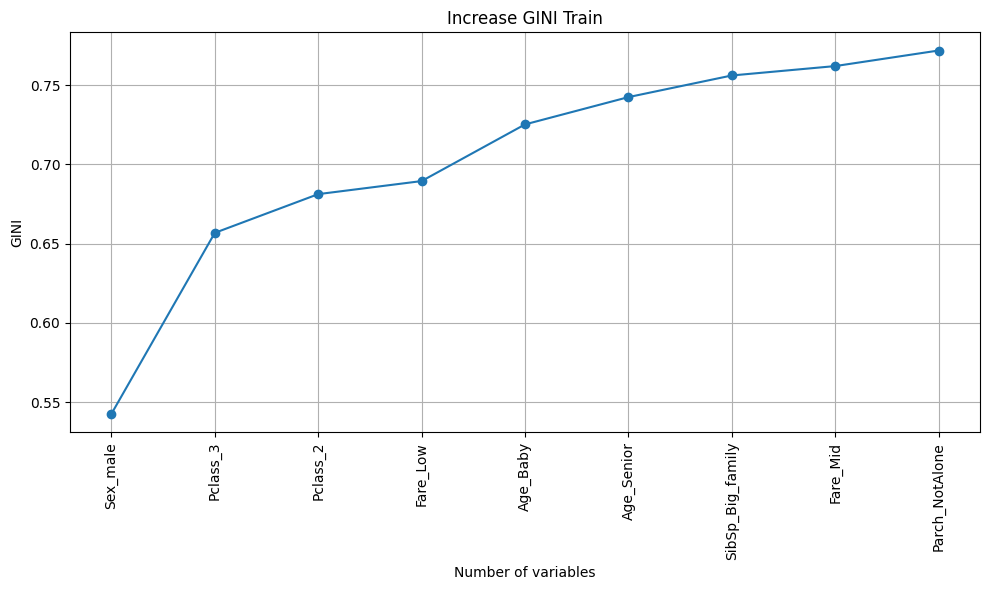

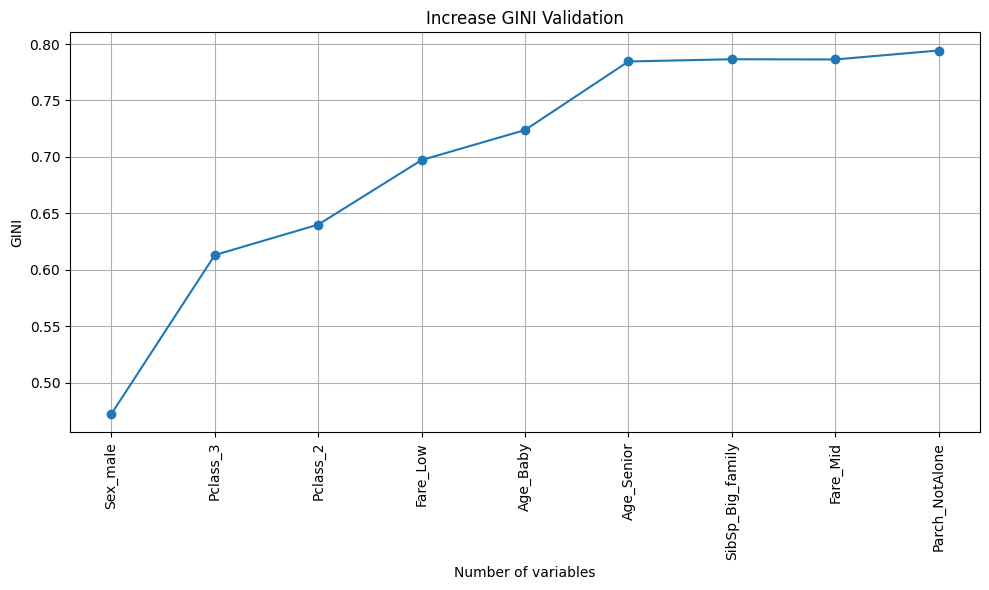

In [1659]:
gini_przyrost(model_best_category, 'Train',X_train_category_del4, Y_train,X_train_category_del4, Y_train, X_val_category_del4, Y_val)
gini_przyrost(model_best_category, 'Validation',X_train_category_del4, Y_train,X_val_category_del4, Y_val, X_val_category_del4, Y_val)


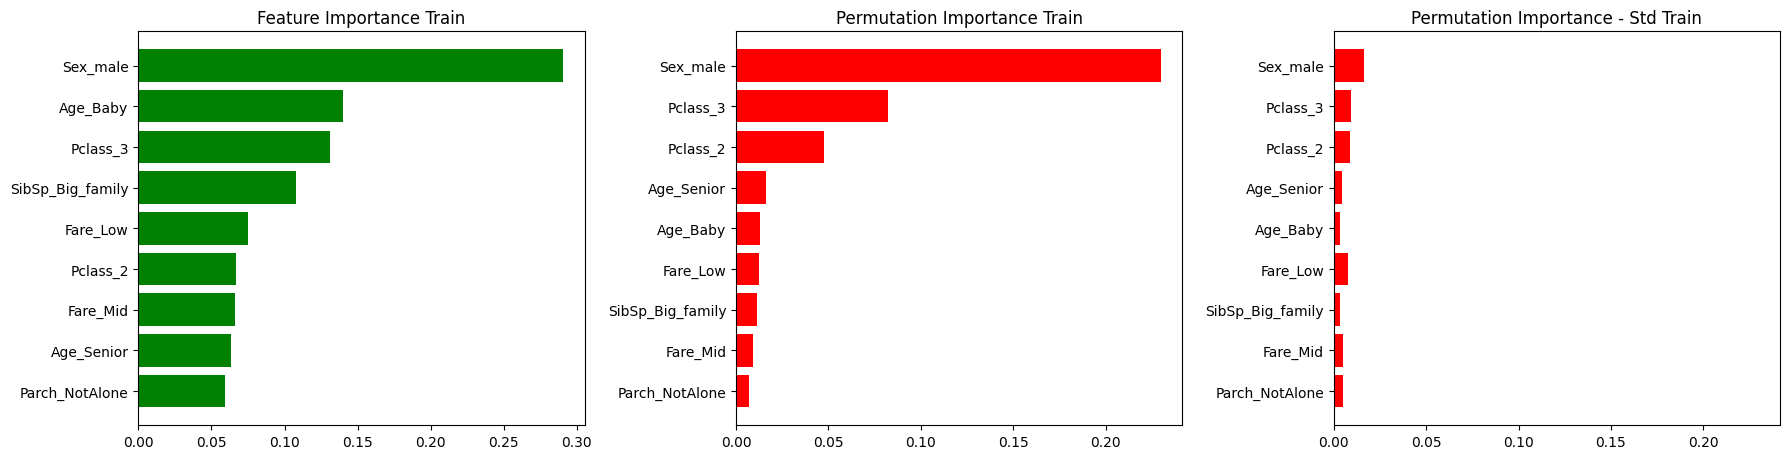

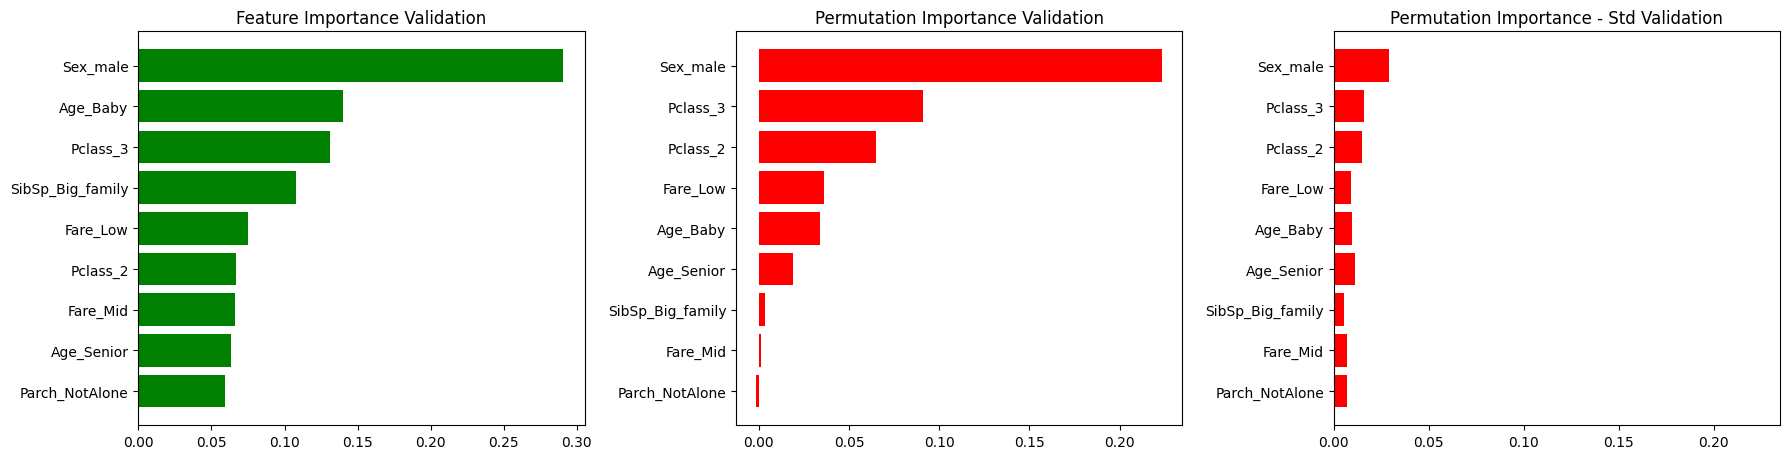

In [1660]:
get_feats_plots(model_best_category,'Train',X_train_category_del4, Y_train)
get_feats_plots(model_best_category,'Validation',X_val_category_del4, Y_val)


SibSp_Big_family does not improve GINI value on validation set. Also it has much higher Feature Importance value on validation set than it has Permuation Importance. That can also cause overfitting and make this variable useless.

In [1661]:
X_train_category_del5 = X_train_category_del4.drop([ 'SibSp_Big_family'  ], axis =1)
X_test_category_del5 = X_test_category_del4.drop(['SibSp_Big_family' ], axis =1)
X_val_category_del5 = X_val_category_del4.drop(['SibSp_Big_family' ], axis =1)

model_best_category.fit(X_train_category_del5, Y_train)

df = pd.concat([df, model_summary(model_best_category, 'Model dummy - categories -  variable deduction 4',X_train_category_del5, Y_train, X_val_category_del5, Y_val)], axis=0)
df

,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685
0,Model dummy - hyperparameters optimization,18,90.263,74.592
0,Model dummy - categories,13,89.099,63.082
0,Model dummy - categories - hyperparameters opt...,13,80.818,70.437
0,Model dummy - categories - variable deduction 1,12,80.149,73.651
0,Model dummy - categories - variable deduction 2,11,77.469,77.341
0,Model dummy - categories - variable deduction 2,10,77.235,79.206
0,Model dummy - categories - variable deduction 3,9,77.163,78.750
0,Model dummy - categories - variable deduction 4,8,76.039,76.667


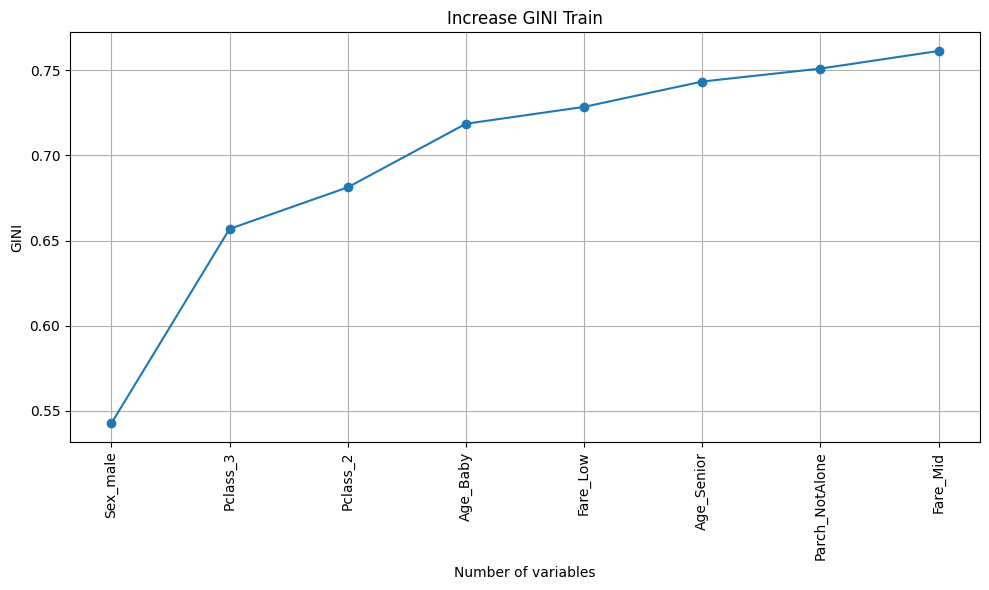

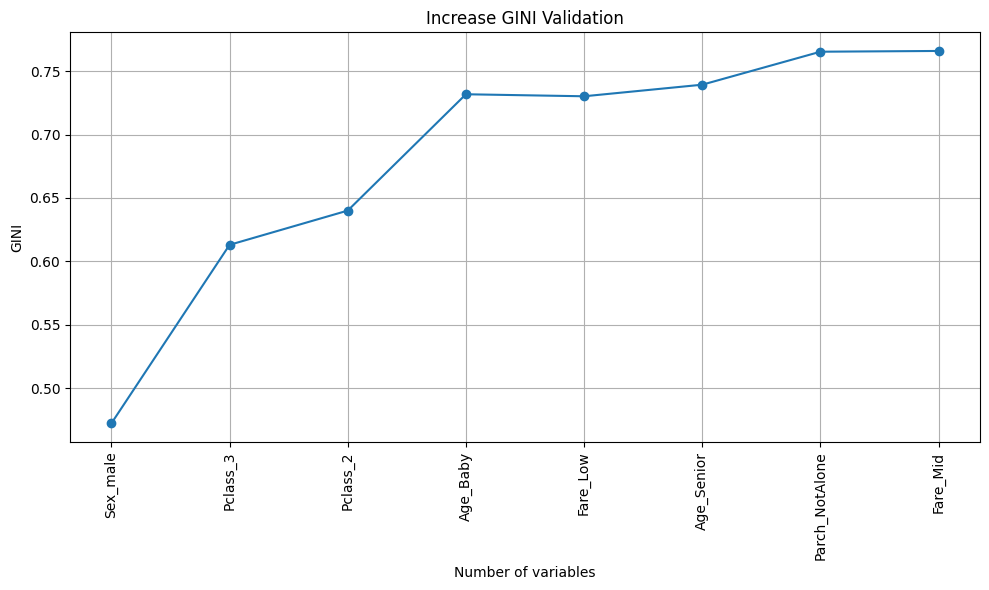

In [1662]:
gini_przyrost(model_best_category, 'Train',X_train_category_del5, Y_train,X_train_category_del5, Y_train, X_val_category_del5, Y_val)
gini_przyrost(model_best_category,'Validation', X_train_category_del5, Y_train,X_val_category_del5, Y_val, X_val_category_del5, Y_val)


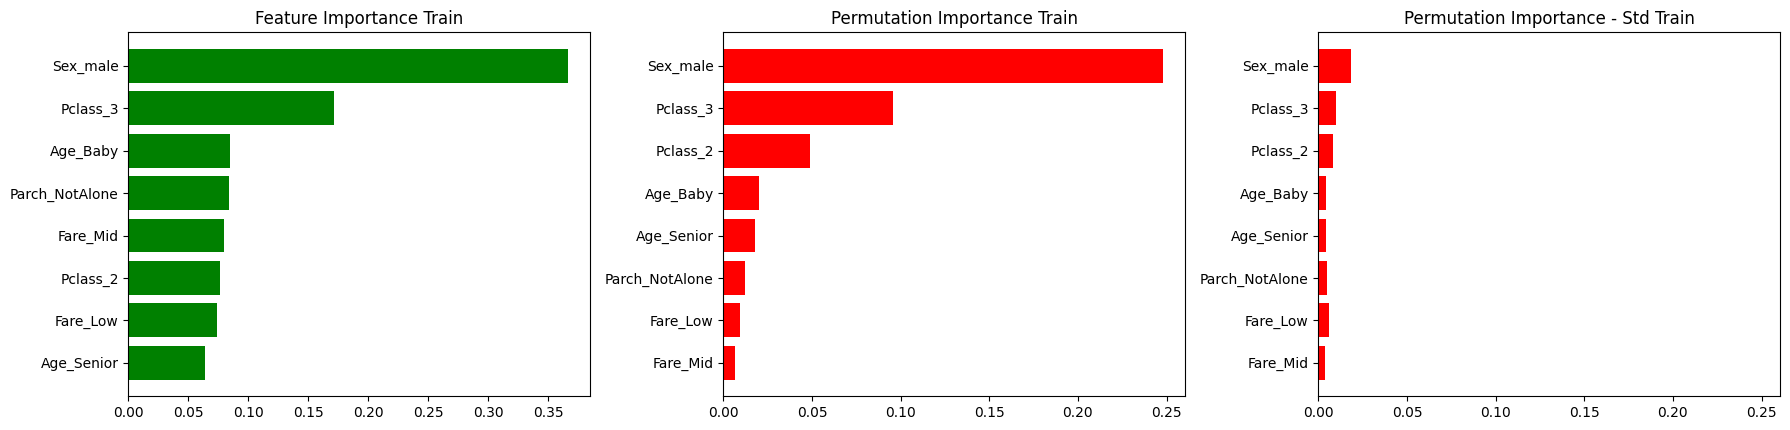

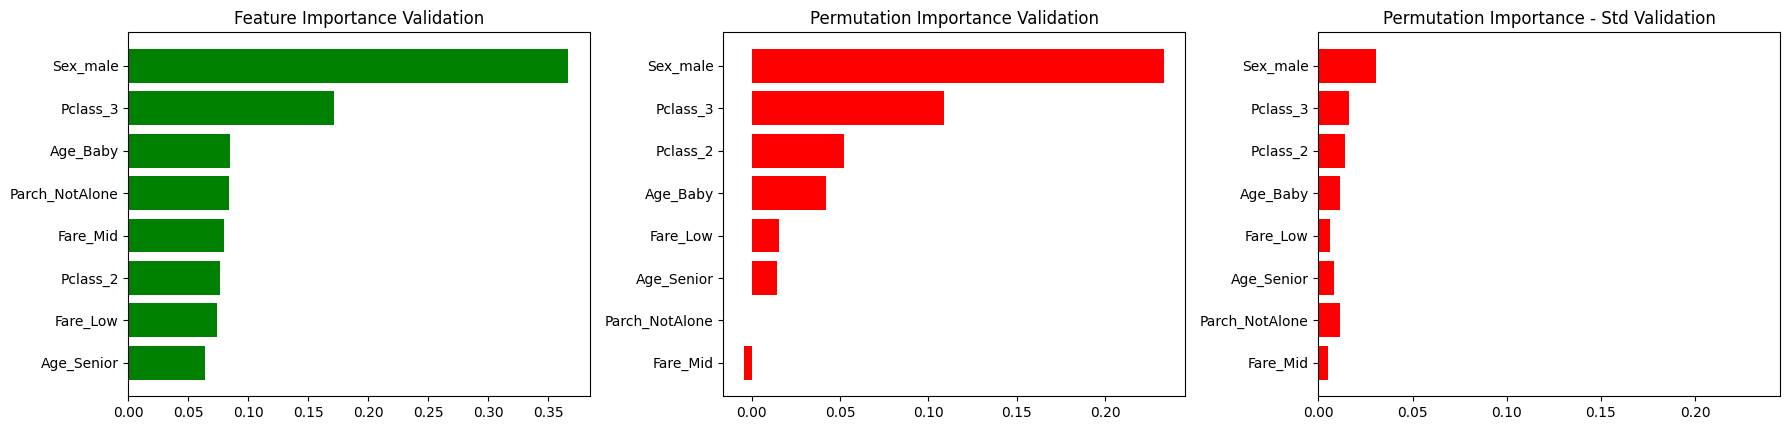

In [1663]:
get_feats_plots(model_best_category,'Train',X_train_category_del5, Y_train)
get_feats_plots(model_best_category,'Validation',X_val_category_del5, Y_val)


Fare_Mid has a negative Permutation Importance value on validation set so we remove it. It doesnt also improve GINI metric.

In [1664]:
X_train_category_del6 = X_train_category_del5.drop([ 'Fare_Mid'  ], axis =1)
X_test_category_del6= X_test_category_del5.drop(['Fare_Mid'  ], axis =1)
X_val_category_del6 = X_val_category_del5.drop([ 'Fare_Mid'  ], axis =1)

model_best_category.fit(X_train_category_del6, Y_train)

df = pd.concat([df, model_summary(model_best_category, 'Model dummy - categories -  variable deduction 5',X_train_category_del6, Y_train, X_val_category_del6, Y_val)], axis=0)
df

,model name,number of predictors,GINI train,GINI test
0,Basic model,7,99.868,69.574
0,Model dummy,18,99.848,71.685
0,Model dummy - hyperparameters optimization,18,90.263,74.592
0,Model dummy - categories,13,89.099,63.082
0,Model dummy - categories - hyperparameters opt...,13,80.818,70.437
0,Model dummy - categories - variable deduction 1,12,80.149,73.651
0,Model dummy - categories - variable deduction 2,11,77.469,77.341
0,Model dummy - categories - variable deduction 2,10,77.235,79.206
0,Model dummy - categories - variable deduction 3,9,77.163,78.750
0,Model dummy - categories - variable deduction 4,8,76.039,76.667


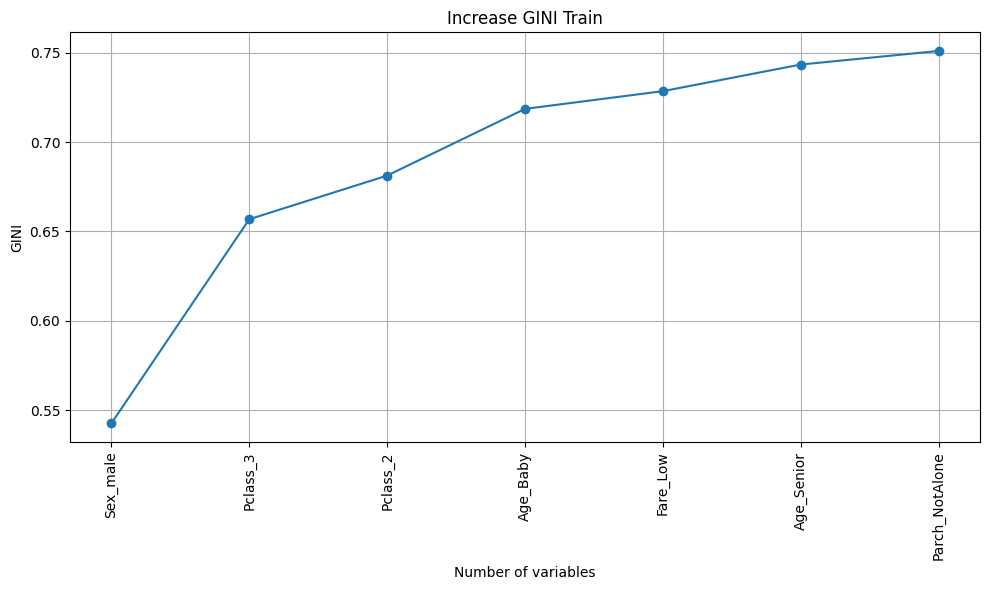

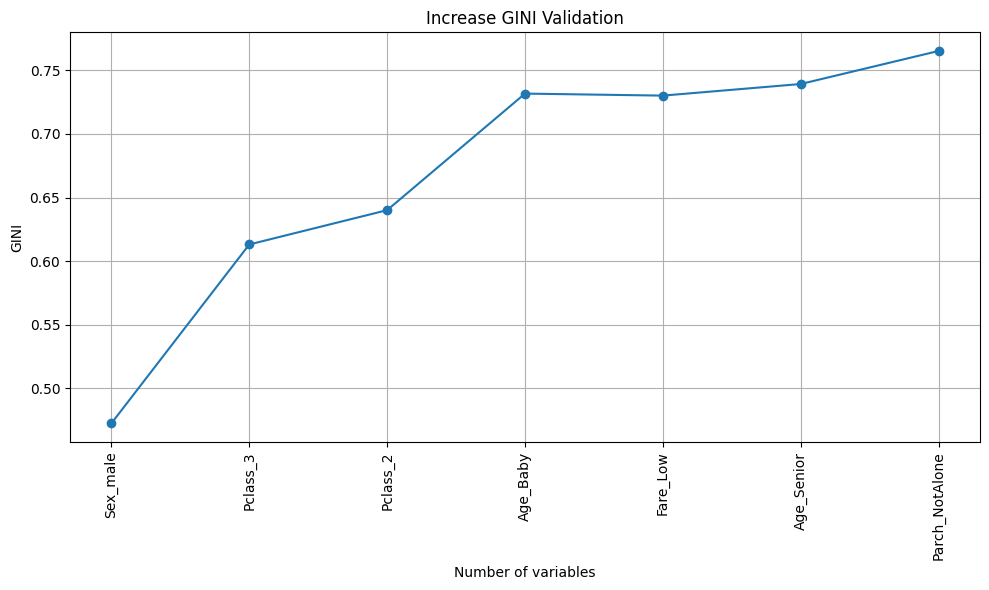

In [1665]:
gini_przyrost(model_best_category, 'Train',X_train_category_del6, Y_train,X_train_category_del6, Y_train, X_val_category_del6, Y_val)
gini_przyrost(model_best_category, 'Validation',X_train_category_del6, Y_train,X_val_category_del6, Y_val, X_val_category_del6, Y_val)


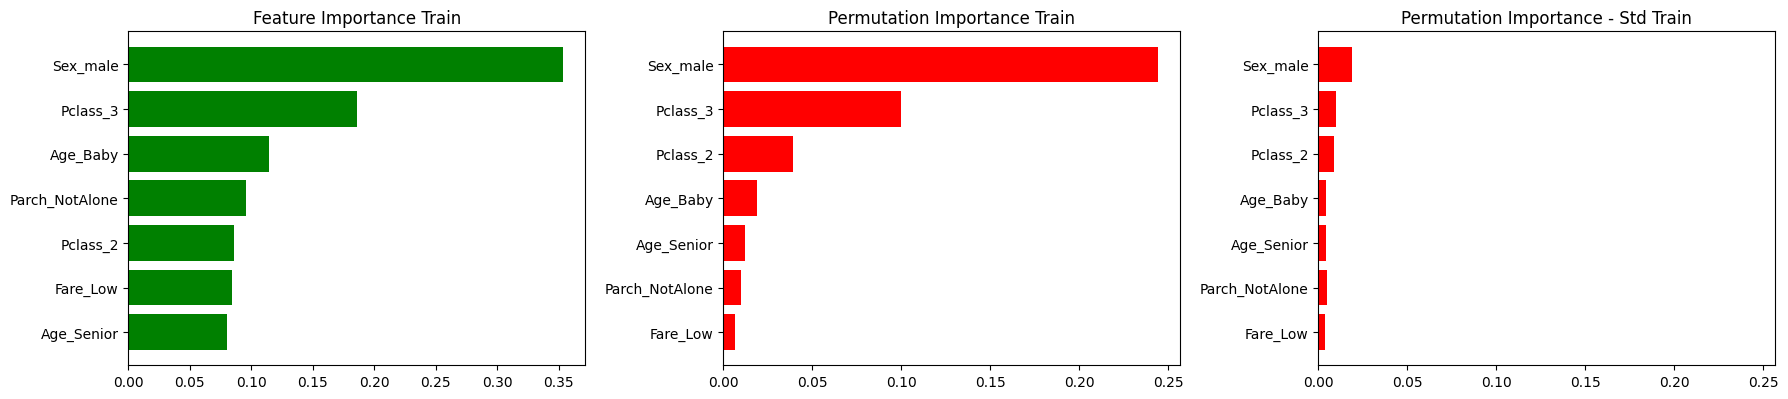

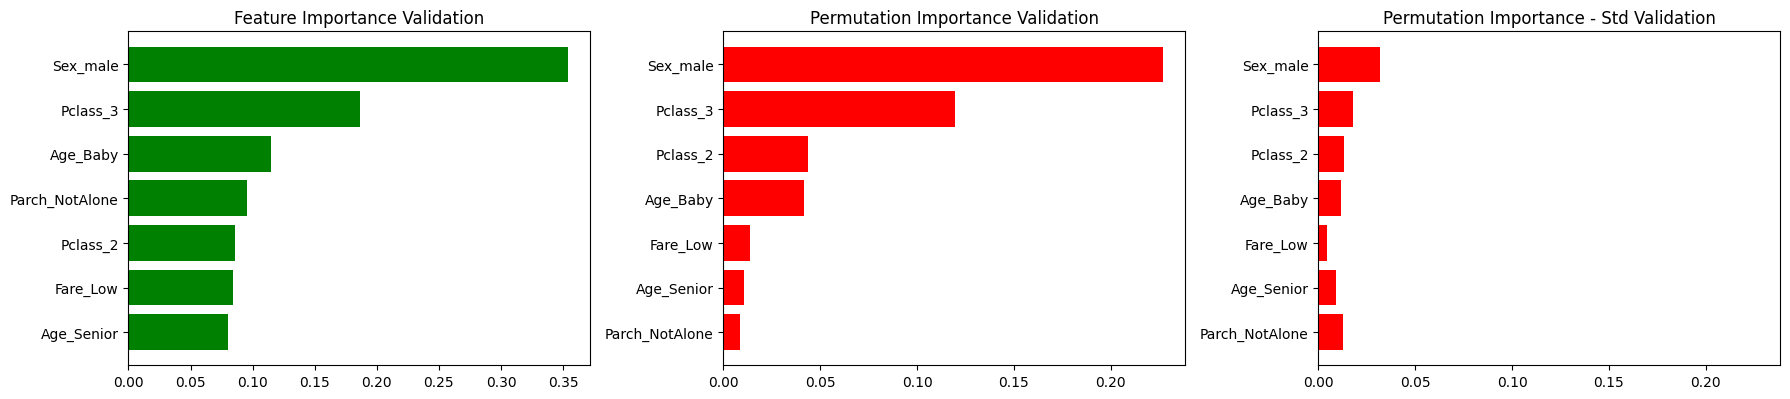

In [1666]:
get_feats_plots(model_best_category,'Train',X_train_category_del6, Y_train)
get_feats_plots(model_best_category,'Validation',X_val_category_del6, Y_val)


That is it! Now we do not have any more variables to remove. We tried to remove Fare_Low variable from the model but then GINI value goes below 0.7 on validation set. That is too much. So we finish with 7 explanatory variables. Just to remind, we started with 13.

In [1667]:
round(gini(Y_test, model_best_category.predict_proba(X_test_category_del6)[:,1])*100,3)

72.62

And on a test set we have GINI value 72.62 so it is less than on the validation set but still it is close to the results that we had on a Train set.

We can also think about cutoff point. In general, we are given in this model the probability of success so we would like to assign specific value to the results - if the passenger will die or not. For instance, 0.8 means survival but 0.34 dead. So cutoff point is the minimal value (in terms of probability) to associate a given result with survival.

We would like to use for this purpose a confussion matrix that tells us how many times the model predicts well that the passenger survives but also how many times it tells us well that a passenger dies.

In [1668]:
def cutoff_point(model, X,Y):
    cutoff = np.arange(0.0,1, 0.001)
    y_pred = model.predict_proba(X)[:,1]

    best_sum = -1
    best_cutoff = None

    for c in cutoff:
        preds = (y_pred >= c).astype(int)
        cm = confusion_matrix(Y, preds)

        TP = cm[1, 1]
        FN = cm[1, 0]
        TN = cm[0, 0]
        FP = cm[0, 1]

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        TNR = TN / (TN + FP) if (TN + FP) > 0 else 0

        tpr_tnr_sum = TPR + TNR

        if tpr_tnr_sum > best_sum:
            best_sum = tpr_tnr_sum
            best_cutoff = c
    return best_cutoff


In [1669]:
cutoff_chosen = cutoff_point(model_best_category, X_train_category_del6, Y_train)

In [1670]:
cutoff_chosen

np.float64(0.28200000000000003)

As you can see, our calculated cutoff point is 0.282 so above this value we will associate a given probability with survival.

In [1671]:
cm1 = pd.Series(model_best_category.predict_proba(X_train_category_del6)[:,1]).apply(lambda x: 1 if x>cutoff_chosen else 0)
cm_train = confusion_matrix(Y_train, cm1)

In [1672]:
cm2 = pd.Series(model_best_category.predict_proba(X_test_category_del6)[:,1]).apply(lambda x: 1 if x>cutoff_chosen else 0)
cm_test = confusion_matrix(Y_test, cm2)

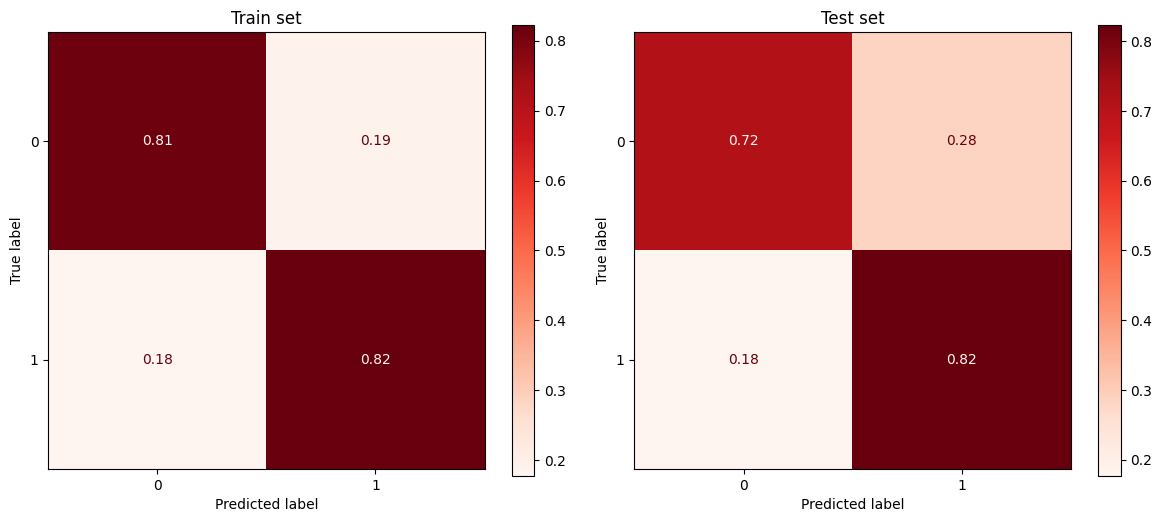

In [1673]:
fix, axes = plt.subplots(1,2, figsize = [12,5])
ConfusionMatrixDisplay.from_predictions(Y_train, cm1, normalize = 'true', cmap = 'Reds',ax=axes[0])
axes[0].set_title("Train set")
ConfusionMatrixDisplay.from_predictions(Y_test, cm2,normalize = 'true', cmap = 'Reds',ax=axes[1])
axes[1].set_title('Test set')

plt.tight_layout()
plt.show()
#disp.plot(cmap = 'Oranges')
#plt.show()

As you can see on a confussion matrix, generally model has a tendency to overestimate the number of survivals when in fact a passenger died. When it comes to situations when a passenger in fact survived it is really stable.

In [1674]:
import shap
explainer=shap.TreeExplainer(model_best_category, X_train_category_del6.astype(float))
shap_values=explainer.shap_values(X_train_category_del6.astype(float))

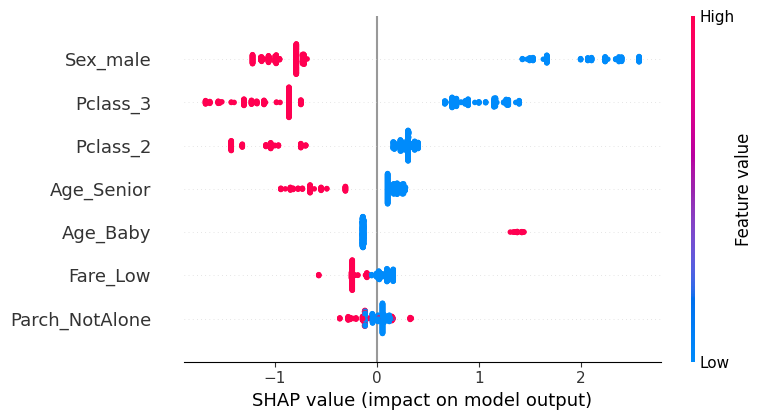

In [1675]:
shap.summary_plot(shap_values, X_train_category_del6)

If we want to understand this model we should look at the shap values. They tell us how the obtained values influence chances for survival or death. For instance, woman had a greater chance to survive than man. Also if a passenger was from the first class. When it comes to age, little kids had a greater chance to survive than elderly people. We can also see that the more a passenger paid for the ticket, the more probable for him was to survive. There can exist a correlation between pclass variable and fare.